In [1]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.font_manager import FontProperties
from scipy.special import genlaguerre    #genlaguerre(n, alpha)
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import MultipleLocator

from matplotlib.lines import Line2D
import ipywidgets as widgets
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import Polygon

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets
from IPython.display import display
import imageio_ffmpeg

In [2]:
#數值設定  
c = 299792458 #m/s
Eg = 1.7 #eV
D_B = 1.89 * 10**(-20) #um*C
D_G = 0.12 * 10**(-20) #um*C
a_0 = 1 #V*s
ZR = 11.81 #um
W = 1.5 #umz
Q_c = 8.6 #um^-1
q = 2*ZR/(W**2) #um-1
w = c*q*10**(-6)
hbar = 6.582119569 * 10**(-16) #eV*s
print("q=",q,"um-1$ \nw=",w,"s^-1 \nLamda=",2*np.pi/q,"um")

def Factorial(n):
    f=1
    for i in range(1,n+1,1):
        f*=i 
    return f

def Laguerre(rho,l,p):
    l = np.abs(l)
    L = 0
    for m in range(p+1):
        L += (-1)**m * Factorial(l+p) / (Factorial(p-m)*Factorial(l+m)*Factorial(m)) * (2*(rho/W)**2)**m
    return L

def f(rho,l,p):
    l = np.abs(l)
    f = np.sqrt((Factorial(p)*2)/(np.pi*Factorial(l+p))) * np.exp(-(rho/W)**2) * (np.sqrt(2)*rho/W)**l * Laguerre(rho,l,p)
    return f 
    
def u(phi,rho,l,p):
    u = f(rho,l,p) * np.exp(complex(0,1)*l*phi)
    return u

q= 10.497777777777777 um-1$ 
w= 3147.154603537778 s^-1 
Lamda= 0.5985252726991562 um


In [3]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0/(10**(-6)) /(10**(12))
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
print(q, w,"THz", ZR)

10.497777777777777 3540.6984347910775 THz 13.286811034919236


In [4]:
import numpy as np
from scipy.constants import c

# ===============================================================
# 光學與物理基礎參數設定
# ===============================================================
Lambda = 0.532                  # 波長 (um)
q_0 = 2 * np.pi / Lambda        # 自由空間波數 (um^-1)
w = c * q_0 / (10**(-6)) / (10**(12))  # 角頻率 (THz)
W_2 = 1.5                       # 光束腰半徑 W0 (um)
ZR = 0.5 * q_0 * (W_2**2)       # 瑞利距離 (um)

# ===============================================================
# 核心 VVB 橫向偏振場物理公式 (Ax, Ay)
# ===============================================================
def Factorial_safe_2(n):
    """計算階乘，防止 Deprecation 警告"""
    n = int(np.abs(n))
    if n <= 0:
        return 1.0
    val = 1.0
    for i in range(1, n + 1):
        val *= i
    return float(val)

def F_2(phiq_val, q_val, l):
    """Laguerre-Gaussian 徑向與軌道角動量振幅分量"""
    abs_l = int(np.abs(l))
    F_val = (np.sqrt(2 * np.pi / Factorial_safe_2(abs_l)) * 
             W_2**2 * (q_val * W_2 / np.sqrt(2))**abs_l * 
             np.exp(-q_val**2 * W_2**2 / 4))
    return F_val

def G_2(phiq_val, q_val, l1, l2, beta):
    """VVB 疊加場 G 分量"""
    return (np.cos(beta/2) * F_2(phiq_val, q_val, l1) + np.sin(beta/2) * F_2(phiq_val, q_val, l2))

def H_2(phiq_val, q_val, l1, l2, beta):
    """VVB 疊加場 H 分量"""
    return (np.cos(beta/2) * F_2(phiq_val, q_val, l1) - np.sin(beta/2) * F_2(phiq_val, q_val, l2))

def VVBx_2(phiq_val, q_val, l1, l2, beta, alpha):
    """橫向偏振場 X 分量 (ux)"""
    Dl = l2 - l1
    Dlbar = np.abs(l2) - np.abs(l1)
    Tl = (l2 + l1) / 2
    Tlbar = (np.abs(l2) + np.abs(l1)) / 2
    
    g_part = G_2(phiq_val, q_val, l1, l2, beta)
    h_part = H_2(phiq_val, q_val, l1, l2, beta)
    
    ux = (np.cos(Dl/2 * phiq_val - np.pi/4 * Dlbar + alpha/2) * g_part - 
          1j * np.sin(Dl/2 * phiq_val - np.pi/4 * Dlbar + alpha/2) * h_part)
    
    ux = 0.5 * np.exp(1j * Tl * phiq_val) * np.exp(1j * (-np.pi/2 * Tlbar + alpha/2)) * ux
    return ux

def VVBy_2(phiq_val, q_val, sigma1, sigma2, l1, l2, beta, alpha):
    """橫向偏振場 Y 分量 (uy)"""
    Dl = l2 - l1
    Dlbar = np.abs(l2) - np.abs(l1)
    Tl = (l2 + l1) / 2
    Tlbar = (np.abs(l2) + np.abs(l1)) / 2
    
    g_part = G_2(phiq_val, q_val, l1, l2, beta)
    h_part = H_2(phiq_val, q_val, l1, l2, beta)
    
    uy = (np.sin(Dl/2 * phiq_val - np.pi/4 * Dlbar + alpha/2) * g_part + 
          1j * np.cos(Dl/2 * phiq_val - np.pi/4 * Dlbar + alpha/2) * h_part)

    uy = 0.5 * np.exp(1j * Tl * phiq_val) * np.exp(1j * (-np.pi/2 * Tlbar + alpha/2)) * uy
    return uy

def VVB_field_components(phiq_val, q_val, l1, l2, sigma1, sigma2, beta, alpha):
    """主繪圖函式對應接頭：整合回傳 Ax, Ay"""
    Ax = VVBx_2(phiq_val, q_val, l1, l2, beta, alpha)
    Ay = VVBy_2(phiq_val, q_val, sigma1, sigma2, l1, l2, beta, alpha)
    return Ax, Ay

Output()

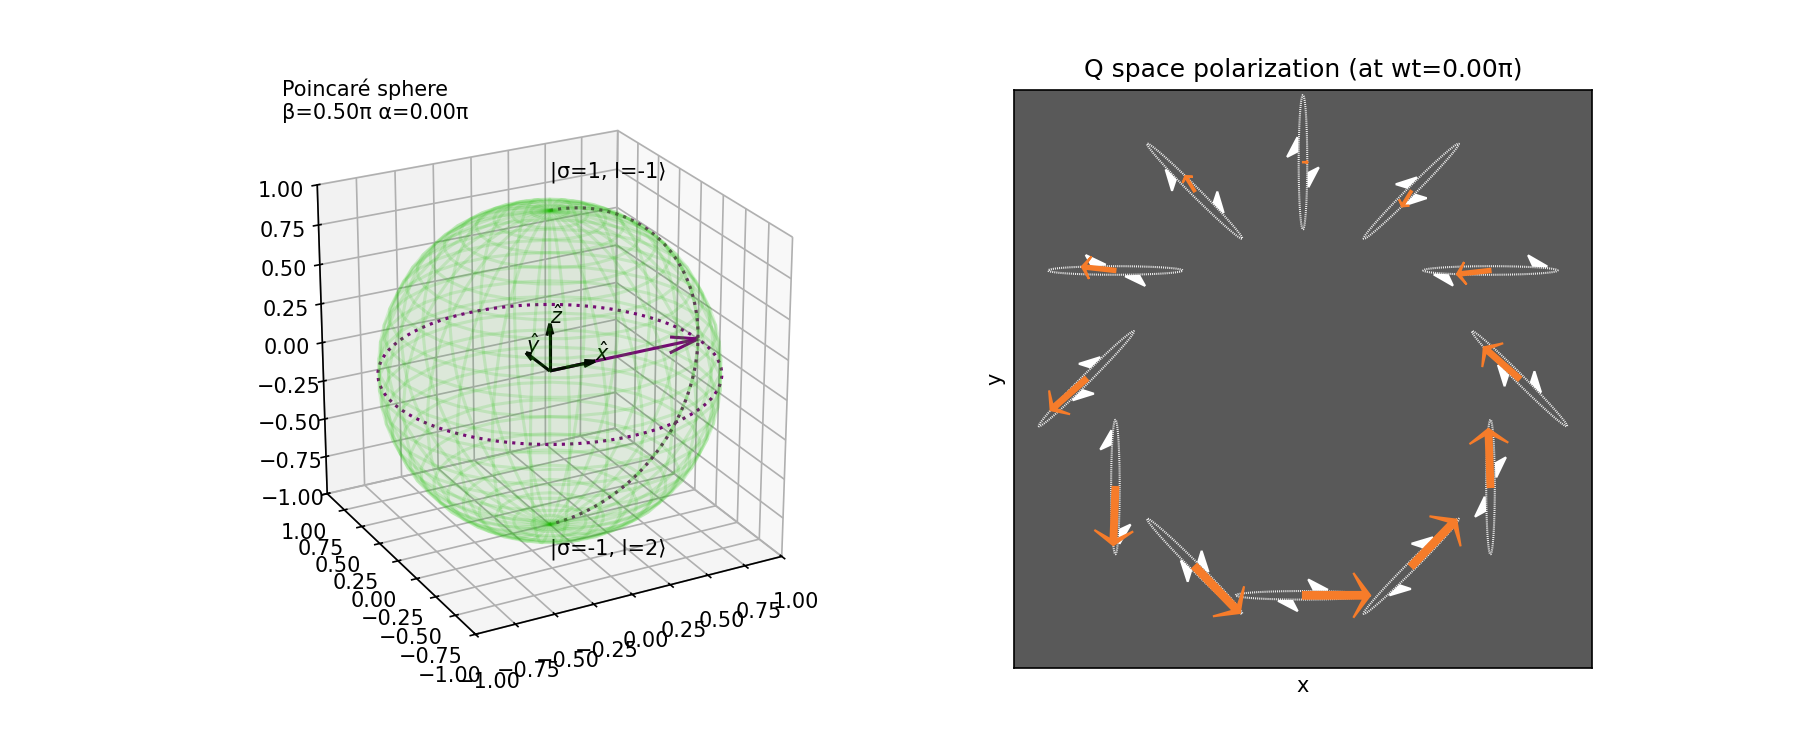

In [34]:
# ===============================================================
# 1. PARAMETERS & INITIAL SETUPS
# ===============================================================
t_arr_2 = np.arange(0, 2*np.pi, 0.02) 
circle_2, polar_2 = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

limit_2 = 0.235 * Q_c

# 🎯【繪圖樣式與尺寸設定】
DASH_LEN = 0.5       # 虛線線段長度 (pt)
GAP_LEN  = 0.5       # 虛線間隔長度 (pt)
TRAJ_LW  = 1         # 虛線軌跡粗細 (lw)

FIN_LEN = 0.05 * limit_2      # 鯊魚鰭沿切線的前進長度
FIN_HEIGHT = 0.035 * limit_2 # 鯊魚鰭向外延伸的高（寬）度

# Sphere mesh
U_2, V_2 = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx_2, sy_2, sz_2 = np.cos(U_2)*np.sin(V_2), np.sin(U_2)*np.sin(V_2), np.cos(V_2)

# Layout & Widgets
fig_2 = plt.figure(figsize=(12, 5), dpi=150)

# 物理與時間滑桿
beta_slider_2 = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider_2 = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
wt_slider_2 = widgets.FloatSlider(value=0, min=0, max=2, step=0.01, description='wt (π)') 

# sigma 選單 (包含 1, -1)
sigma1_box_2 = widgets.Dropdown(options=[1, -1], value=1, description='σ1')
sigma2_box_2 = widgets.Dropdown(options=[1, -1], value=-1, description='σ2')

l1_box_2 = widgets.IntText(value=-1, description='l')
l2_box_2 = widgets.IntText(value=2, description="l'")
p_box_2 = widgets.IntText(value=0, description='p')

arrow_checkbox_2 = widgets.Checkbox(value=True, description='Show Direction Arrows')


# ===============================================================
# 2. HELPER FUNCTIONS
# ===============================================================
def create_shark_fin(px_raw, py_raw, tx, ty, rx, ry, fin_len, fin_height, offset):
    """計算外擴且沿切線方向的鯊魚鰭多邊形頂點"""
    n1_x, n1_y = -ty, tx
    nx, ny = (n1_x, n1_y) if (n1_x * rx + n1_y * ry) > 0 else (ty, -tx)

    px = px_raw + nx * offset
    py = py_raw + ny * offset

    p1 = (px, py)
    p2 = (px + tx * fin_len, py + ty * fin_len)
    p3 = (
        px - tx * (0.37 * fin_len) + nx * fin_height, 
        py - ty * (0.37 * fin_len) + ny * fin_height
    )
    return Polygon([p1, p2, p3], closed=True, color='white', zorder=2)


# ===============================================================
# 3. UPDATE PLOT FUNCTION
# ===============================================================
def update_plot_full_transverse(l1, l2, p, sigma1, sigma2, beta, alpha, wt, show_arrows=True):
    beta_rad, alpha_rad = beta * np.pi, alpha * np.pi
    wt_rad = wt * np.pi 
    
    fig_2.clear()
    ax3D = fig_2.add_subplot(1, 2, 1, projection='3d')
    ax_pol = fig_2.add_subplot(1, 2, 2)
    
    for ax in [ax3D, ax_pol]: 
        ax.set_aspect('equal')

    # ---------------------------------------------------
    # 1. Poincaré Sphere
    # ---------------------------------------------------
    ax3D.plot_wireframe(sx_2, sy_2, sz_2, color=(0.15, 0.8, 0.05, 0.15))
    ax3D.plot_surface(sx_2, sy_2, sz_2, color=(0.15, 0.8, 0.05, 0.05))
    
    qx, qy, qz = np.cos(alpha_rad)*np.sin(beta_rad), np.sin(alpha_rad)*np.sin(beta_rad), np.cos(beta_rad)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    ax3D.plot(np.sin(beta_rad)*np.cos(circle_2), np.sin(beta_rad)*np.sin(circle_2), np.cos(beta_rad)+0*circle_2, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar_2)*np.cos(alpha_rad), np.sin(polar_2)*np.sin(alpha_rad), np.cos(polar_2), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta:.2f}π α={alpha:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): 
        ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩')
    ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1, 1); ax3D.set_ylim(-1, 1); ax3D.set_zlim(-1, 1); ax3D.view_init(24, -118)
    
    # ---------------------------------------------------
    # 2. Polarization Map
    # ---------------------------------------------------
    ax_pol.set_facecolor((89/255.0, 89/255.0, 89/255.0))
    
    dt = 0.005              # 切線微小時間步長
    dt_advance = 0.05 * np.pi  # 鯊魚鰭從短軸頂點順方向滑開的相位距離
    fin_offset = 0.005 * limit_2
    
    angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
    R = 0.75 * limit_2
    
    for ang in angles:
        cx, cy = R * np.cos(ang), R * np.sin(ang)

        scale = 0.25
        # 🎯 使用新的 VVB_field_components 計算 Ax 與 Ay
        Ax, Ay = VVB_field_components(ang, R, l1, l2, sigma1, sigma2, beta_rad, alpha_rad)
        a = scale * Ax
        b = scale * Ay

        # 1. 繪製偏振軌跡
        traj_x = cx + np.real(a * np.exp(-1j * t_arr_2))
        traj_y = cy + np.real(b * np.exp(-1j * t_arr_2))
        ax_pol.plot(traj_x, traj_y, color='white', dashes=(DASH_LEN, GAP_LEN), alpha=0.9, lw=TRAJ_LW, zorder=2)

        # 2. 瞬時電場箭頭
        Ex_t = np.real(a * np.exp(-1j * wt_rad))
        Ey_t = np.real(b * np.exp(-1j * wt_rad))
        r_len = np.hypot(Ex_t, Ey_t)

        if r_len > 1e-5:
            norm_factor = r_len / (0.03 * limit_2)
            ax_pol.arrow(
                cx, cy, Ex_t, Ey_t,
                width=0.003 * limit_2 * norm_factor,
                head_width=0.02 * limit_2 * norm_factor,
                head_length=0.25 * r_len,
                overhang=0.6,
                length_includes_head=True,
                color=(246/255.0, 124/255.0, 42/255.0),
                zorder=3
            )

        # 3. 繪製鯊魚鰭 (方向箭頭)
        if show_arrows:
            top = 2 * np.real(a * np.conj(b))
            bottom = np.real(a**2 + b**2)
            t_cand = 0.5 * np.arctan2(top, bottom)
            
            r1_sq = np.real(a * np.exp(-1j * t_cand))**2 + np.real(b * np.exp(-1j * t_cand))**2
            r2_sq = np.real(a * np.exp(-1j * (t_cand + np.pi/2)))**2 + np.real(b * np.exp(-1j * (t_cand + np.pi/2)))**2
            t_minor = t_cand if r1_sq < r2_sq else t_cand + np.pi / 2

            for t_base in [t_minor, t_minor + np.pi]:
                t_phase = t_base + dt_advance

                px_raw = cx + np.real(a * np.exp(-1j * t_phase))
                py_raw = cy + np.real(b * np.exp(-1j * t_phase))
                px_next = cx + np.real(a * np.exp(-1j * (t_phase + dt)))
                py_next = cy + np.real(b * np.exp(-1j * (t_phase + dt)))

                tx, ty = px_next - px_raw, py_next - py_raw
                t_len = np.hypot(tx, ty)

                if t_len > 1e-6:
                    tx /= t_len
                    ty /= t_len
                    rx, ry = px_raw - cx, py_raw - cy

                    if np.hypot(rx, ry) > 1e-6:
                        fin_poly = create_shark_fin(
                            px_raw, py_raw, tx, ty, rx, ry, 
                            FIN_LEN, FIN_HEIGHT, fin_offset
                        )
                        ax_pol.add_patch(fin_poly)

    ax_pol.set_xticks([])
    ax_pol.set_yticks([])
    ax_pol.set_title(f"Q space polarization (at wt={wt:.2f}π)")
    ax_pol.set_xlabel("x")
    ax_pol.set_ylabel("y")
    ax_pol.set_xlim(-limit_2, limit_2)
    ax_pol.set_ylim(-limit_2, limit_2)


# ===============================================================
# 4. UI LAYOUT & INTERACTIVE DISPLAY
# ===============================================================
out_2 = widgets.interactive_output(update_plot_full_transverse, {
    'l1': l1_box_2, 
    'l2': l2_box_2, 
    'p': p_box_2, 
    'sigma1': sigma1_box_2,
    'sigma2': sigma2_box_2,
    'beta': beta_slider_2,
    'alpha': alpha_slider_2,
    'wt': wt_slider_2,
    'show_arrows': arrow_checkbox_2
})

ui_2 = widgets.VBox([
    widgets.Label("### 1. Physics Coefficients ###"), 
    widgets.HBox([sigma1_box_2, sigma2_box_2, l1_box_2, l2_box_2, p_box_2]), 
    
    widgets.Label("### 2. Space & Time Parameters ###"), 
    widgets.HBox([beta_slider_2, alpha_slider_2, wt_slider_2, arrow_checkbox_2])
])

display(ui_2, out_2)

Output()

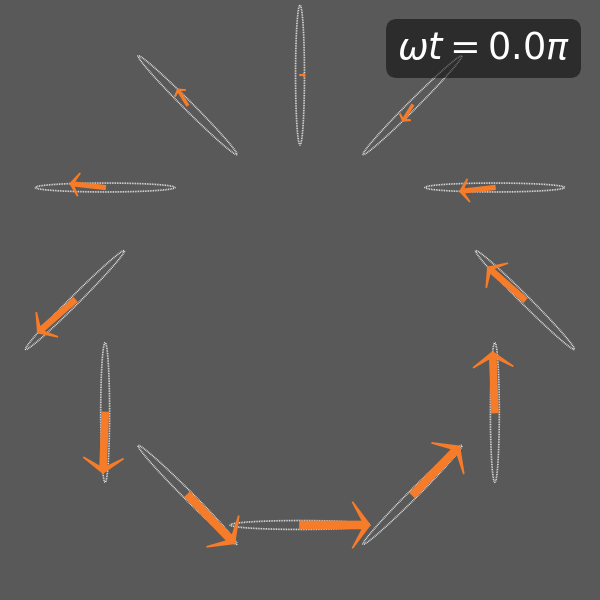

In [35]:
# ===============================================================
# 1. PARAMETERS & INITIAL SETUPS
# ===============================================================
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"
t_arr_2 = np.arange(0, 2*np.pi, 0.02) 
limit_2 = 0.235 * Q_c
bg_color = (89/255.0, 89/255.0, 89/255.0)

fig_2 = plt.figure(figsize=(5, 5), dpi=120, facecolor=bg_color)

# UI 元件設定
beta_slider_2 = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider_2 = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
wt_slider_2 = widgets.FloatSlider(value=0, min=0, max=2, step=0.01, description='wt (π)') 
sigma1_box_2, sigma2_box_2 = widgets.Dropdown(options=[1, -1], value=1, description='σ1'), widgets.Dropdown(options=[1, -1], value=-1, description='σ2')
l1_box_2, l2_box_2, p_box_2 = widgets.IntText(value=-1, description='l'), widgets.IntText(value=2, description="l'"), widgets.IntText(value=0, description='p')

export_button = widgets.Button(description="匯出單一 MP4", button_style='primary', icon='video-camera')
export_all_button = widgets.Button(description="批次匯出全部 12 個 MP4", button_style='success', icon='film')
status_output = widgets.Output()


# ===============================================================
# 2. UPDATE PLOT FUNCTION
# ===============================================================
def update_plot_full_transverse(l1, l2, p, sigma1, sigma2, beta, alpha, wt):
    fig_2.clear()
    fig_2.patch.set_facecolor(bg_color)
    
    ax_pol = fig_2.add_axes([0, 0, 1, 1], facecolor=bg_color)
    ax_pol.set_aspect('equal')
    
    beta_rad, alpha_rad, wt_rad = beta * np.pi, alpha * np.pi, wt * np.pi 
    R = 0.75 * limit_2
    
    for ang in np.linspace(0, 2*np.pi, 12, endpoint=False):
        cx, cy = R * np.cos(ang), R * np.sin(ang)
        Ax, Ay = VVB_field_components(ang, R, l1, l2, sigma1, sigma2, beta_rad, alpha_rad)
        a, b = 0.25 * Ax, 0.25 * Ay

        # 繪製偏振軌跡
        ax_pol.plot(cx + np.real(a * np.exp(-1j * t_arr_2)), cy + np.real(b * np.exp(-1j * t_arr_2)), 
                    color='white', dashes=(0.5, 0.5), alpha=0.9, lw=1, zorder=2)

        # 瞬時電場箭頭
        Ex_t, Ey_t = np.real(a * np.exp(-1j * wt_rad)), np.real(b * np.exp(-1j * wt_rad))
        r_len = np.hypot(Ex_t, Ey_t)
        if r_len > 1e-5:
            norm_factor = r_len / (0.03 * limit_2)
            ax_pol.arrow(cx, cy, Ex_t, Ey_t, width=0.003 * limit_2 * norm_factor, head_width=0.02 * limit_2 * norm_factor,
                         head_length=0.25 * r_len, overhang=0.6, length_includes_head=True, color=(246/255.0, 124/255.0, 42/255.0), zorder=3)

    ax_pol.axis('off')
    ax_pol.set_xlim(-limit_2, limit_2)
    ax_pol.set_ylim(-limit_2, limit_2)

    # 右上角 wt 標記 (黑色半透明框)
    ax_pol.text(0.95, 0.95, f"$\omega t = {wt:.1f}\pi$", transform=ax_pol.transAxes, color='white', 
                fontsize=22, fontweight='bold', ha='right', va='top', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5, edgecolor='none'))


# ===============================================================
# 3. ANIMATION EXPORT LOGIC
# ===============================================================
def render_and_save(l1, l2, p, sigma1, sigma2, beta, alpha, file_name):
    plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
    anim = animation.FuncAnimation(fig_2, lambda wt: update_plot_full_transverse(l1, l2, p, sigma1, sigma2, beta, alpha, wt), frames=np.linspace(0, 2, 100), interval=50)
    
    full_path = os.path.join(SAVE_DIR, file_name)
    writer = animation.FFMpegWriter(fps=20, codec='h264', bitrate=1800, extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2'])
    anim.save(full_path, writer=writer, dpi=120, savefig_kwargs={'facecolor': bg_color, 'bbox_inches': 'tight', 'pad_inches': 0})
    return full_path

def start_export(batch=False):
    with status_output:
        status_output.clear_output()
        os.makedirs(SAVE_DIR, exist_ok=True)
        
        p, s1, s2 = p_box_2.value, sigma1_box_2.value, sigma2_box_2.value
        b_val, a_val = beta_slider_2.value, alpha_slider_2.value
        targets = [(l1_box_2.value, l2_box_2.value)] if not batch else [(l1, l2) for l1 in [-1, 0, 1] for l2 in [-1, 0, 1, 2]]
        
        print(f"🚀 開始渲染 {'批次' if batch else '單一'} 影片，共 {len(targets)} 個檔案...")
        for idx, (l1, l2) in enumerate(targets, 1):
            fname = f"l_{l1}_lp_{l2}.mp4"
            print(f"[{idx}/{len(targets)}] 渲染中: {fname} ...")
            try:
                render_and_save(l1, l2, p, s1, s2, b_val, a_val, fname)
            except Exception as e:
                print(f"❌ {fname} 失敗: {e}")
        print("🎉 任務完成！")

export_button.on_click(lambda b: start_export(batch=False))
export_all_button.on_click(lambda b: start_export(batch=True))


# ===============================================================
# 4. UI DISPLAY
# ===============================================================
out_2 = widgets.interactive_output(update_plot_full_transverse, {
    'l1': l1_box_2, 'l2': l2_box_2, 'p': p_box_2, 'sigma1': sigma1_box_2, 'sigma2': sigma2_box_2,
    'beta': beta_slider_2, 'alpha': alpha_slider_2, 'wt': wt_slider_2
})

display(widgets.VBox([
    widgets.Label("### 1. Physics Coefficients ###"), 
    widgets.HBox([sigma1_box_2, sigma2_box_2, l1_box_2, l2_box_2, p_box_2]), 
    widgets.Label("### 2. Space & Time Parameters ###"), 
    widgets.HBox([beta_slider_2, alpha_slider_2, wt_slider_2]),
    widgets.Label("### 3. MP4 Export Control ###"),
    widgets.HBox([export_button, export_all_button]),
    status_output
]), out_2)

Output()

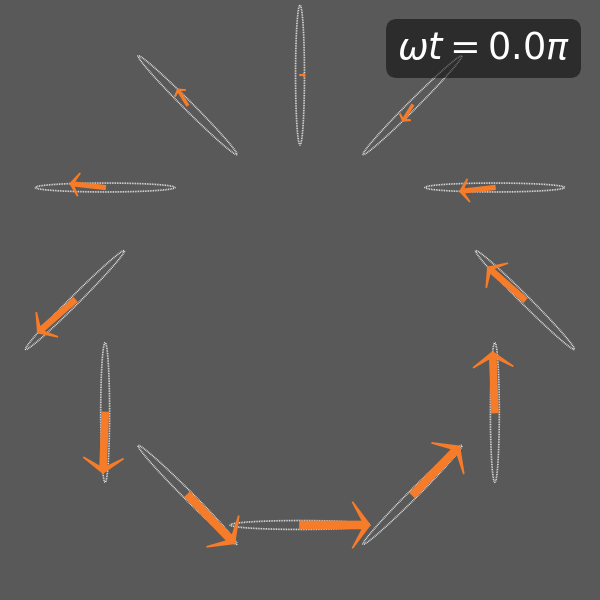

In [36]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
import ipywidgets as widgets
from IPython.display import display

# ===============================================================
# 1. PARAMETERS & INITIAL SETUPS
# ===============================================================
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"
t_arr_2 = np.arange(0, 2*np.pi, 0.02) 
limit_2 = 0.235 * Q_c
bg_color = (89/255.0, 89/255.0, 89/255.0)

fig_2 = plt.figure(figsize=(5, 5), dpi=120, facecolor=bg_color)

# UI 元件設定
beta_slider_2 = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider_2 = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
wt_slider_2 = widgets.FloatSlider(value=0, min=0, max=2, step=0.01, description='wt (π)') 
sigma1_box_2, sigma2_box_2 = widgets.Dropdown(options=[1, -1], value=1, description='σ1'), widgets.Dropdown(options=[1, -1], value=-1, description='σ2')
l1_box_2, l2_box_2, p_box_2 = widgets.IntText(value=-1, description='l'), widgets.IntText(value=2, description="l'"), widgets.IntText(value=0, description='p')

export_button = widgets.Button(description="匯出單一 MP4", button_style='primary', icon='video-camera')
export_all_button = widgets.Button(description="批次匯出 l' (-1,0,1,2) MP4", button_style='success', icon='film', layout=widgets.Layout(width='280px'))
status_output = widgets.Output()


# ===============================================================
# 2. UPDATE PLOT FUNCTION
# ===============================================================
def update_plot_full_transverse(l1, l2, p, sigma1, sigma2, beta, alpha, wt):
    fig_2.clear()
    fig_2.patch.set_facecolor(bg_color)
    
    ax_pol = fig_2.add_axes([0, 0, 1, 1], facecolor=bg_color)
    ax_pol.set_aspect('equal')
    
    beta_rad, alpha_rad, wt_rad = beta * np.pi, alpha * np.pi, wt * np.pi 
    R = 0.75 * limit_2
    
    for ang in np.linspace(0, 2*np.pi, 12, endpoint=False):
        cx, cy = R * np.cos(ang), R * np.sin(ang)
        Ax, Ay = VVB_field_components(ang, R, l1, l2, sigma1, sigma2, beta_rad, alpha_rad)
        a, b = 0.25 * Ax, 0.25 * Ay

        # 繪製偏振軌跡
        ax_pol.plot(cx + np.real(a * np.exp(-1j * t_arr_2)), cy + np.real(b * np.exp(-1j * t_arr_2)), 
                    color='white', dashes=(0.5, 0.5), alpha=0.9, lw=1, zorder=2)

        # 瞬時電場箭頭
        Ex_t, Ey_t = np.real(a * np.exp(-1j * wt_rad)), np.real(b * np.exp(-1j * wt_rad))
        r_len = np.hypot(Ex_t, Ey_t)
        if r_len > 1e-5:
            norm_factor = r_len / (0.03 * limit_2)
            ax_pol.arrow(cx, cy, Ex_t, Ey_t, width=0.003 * limit_2 * norm_factor, head_width=0.02 * limit_2 * norm_factor,
                         head_length=0.25 * r_len, overhang=0.6, length_includes_head=True, color=(246/255.0, 124/255.0, 42/255.0), zorder=3)

    ax_pol.axis('off')
    ax_pol.set_xlim(-limit_2, limit_2)
    ax_pol.set_ylim(-limit_2, limit_2)

    # 右上角 wt 標記 (黑色半透明框)
    ax_pol.text(0.95, 0.95, f"$\omega t = {wt:.1f}\pi$", transform=ax_pol.transAxes, color='white', 
                fontsize=22, fontweight='bold', ha='right', va='top', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5, edgecolor='none'))


# ===============================================================
# 3. ANIMATION EXPORT LOGIC
# ===============================================================
def render_and_save(l1, l2, p, sigma1, sigma2, beta, alpha, file_name):
    plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
    anim = animation.FuncAnimation(fig_2, lambda wt: update_plot_full_transverse(l1, l2, p, sigma1, sigma2, beta, alpha, wt), frames=np.linspace(0, 2, 100), interval=50)
    
    full_path = os.path.join(SAVE_DIR, file_name)
    writer = animation.FFMpegWriter(fps=20, codec='h264', bitrate=1800, extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2'])
    anim.save(full_path, writer=writer, dpi=120, savefig_kwargs={'facecolor': bg_color, 'bbox_inches': 'tight', 'pad_inches': 0})
    return full_path

def start_export(batch=False):
    export_button.disabled = True
    export_all_button.disabled = True
    
    with status_output:
        status_output.clear_output()
        os.makedirs(SAVE_DIR, exist_ok=True)
        
        p, s1, s2 = p_box_2.value, sigma1_box_2.value, sigma2_box_2.value
        b_val, a_val = beta_slider_2.value, alpha_slider_2.value
        current_l1 = l1_box_2.value
        
        # 🎯 批次模式下固定 l1，改變 l' (l2 = -1, 0, 1, 2)
        targets = [(current_l1, l2_box_2.value)] if not batch else [(current_l1, l2) for l2 in [-1, 0, 1, 2]]
        
        print(f"🚀 開始渲染 {'批次' if batch else '單一'} 影片，共 {len(targets)} 個檔案...")
        for idx, (l1, l2) in enumerate(targets, 1):
            # 🎯 檔名增加 alpha 資訊
            fname = f"l_{l1}_lp_{l2}_alpha_{a_val:.2f}pi.mp4"
            print(f"[{idx}/{len(targets)}] 渲染中: {fname} ...")
            try:
                render_and_save(l1, l2, p, s1, s2, b_val, a_val, fname)
                print(f"    ✅ 完成！")
            except Exception as e:
                print(f"❌ {fname} 失敗: {e}")
        print("🎉 任務完成！")
        
    export_button.disabled = False
    export_all_button.disabled = False

export_button.on_click(lambda b: start_export(batch=False))
export_all_button.on_click(lambda b: start_export(batch=True))


# ===============================================================
# 4. UI DISPLAY
# ===============================================================
out_2 = widgets.interactive_output(update_plot_full_transverse, {
    'l1': l1_box_2, 'l2': l2_box_2, 'p': p_box_2, 'sigma1': sigma1_box_2, 'sigma2': sigma2_box_2,
    'beta': beta_slider_2, 'alpha': alpha_slider_2, 'wt': wt_slider_2
})

display(widgets.VBox([
    widgets.Label("### 1. Physics Coefficients ###"), 
    widgets.HBox([sigma1_box_2, sigma2_box_2, l1_box_2, l2_box_2, p_box_2]), 
    widgets.Label("### 2. Space & Time Parameters ###"), 
    widgets.HBox([beta_slider_2, alpha_slider_2, wt_slider_2]),
    widgets.Label("### 3. MP4 Export Control ###"),
    widgets.HBox([export_button, export_all_button]),
    status_output
]), out_2)

In [18]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0*10**(-6)
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
Qc = 8.6 #um-1
print(q_0, w, ZR)

def F(phiq,q,l):
    # F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    F = np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha, wt):
    
    DJ = l2-l1+sigma2-sigma1
    TJ = (l2+l1+sigma2+sigma1)/2
    Dabsl = np.abs(l2)-np.abs(l1)
    Tabsl = (np.abs(l2)+np.abs(l1))/2
    
    VVBuz = np.cos(TJ*phiq-np.pi*Tabsl/2+alpha/2-wt)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  -  np.sin(TJ*phiq-np.pi*Tabsl/2+alpha/2-wt)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = np.cos(TJ*phiq-np.pi*Tabsl/2+alpha/2-wt)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = - np.sin(TJ*phiq-np.pi*Tabsl/2+alpha/2-wt)*np.cos((DJ*phiq+alpha-np.pi*Dabsl/2+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))*5
    
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2)) * VVBuz
    VVBuz = np.real(VVBuz)
    # VVBuz = np.imag(VVBuz)
    return VVBuz

print('T=2*pi/w=',2*np.pi/w)

11.810498697705988 3540.698434791077 13.286811034919236
T=2*pi/w= 0.0017745609864541691


Output()

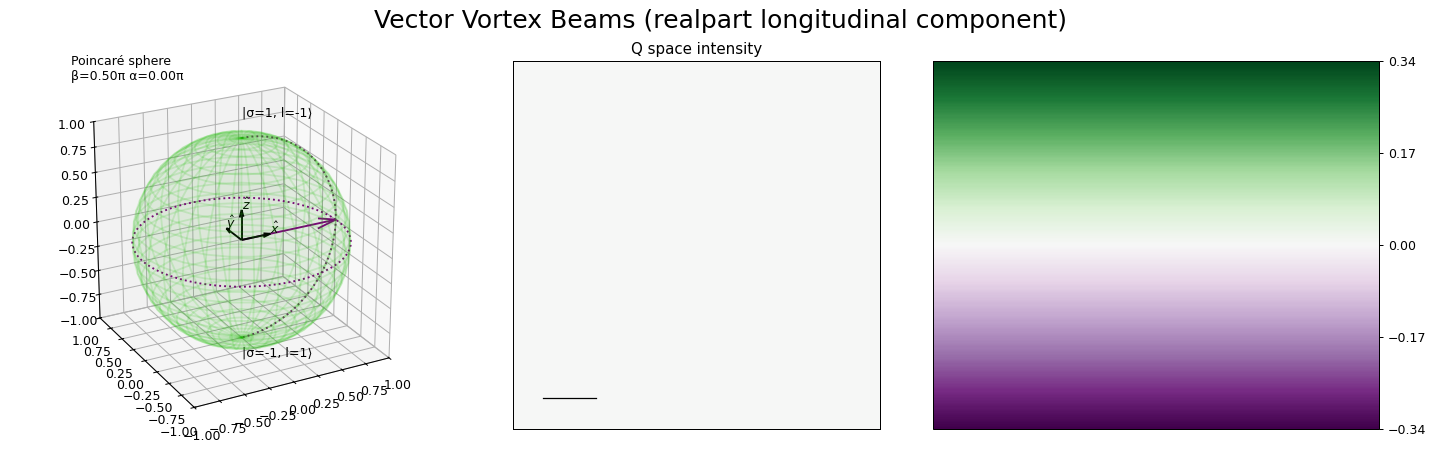

In [19]:
# ===============================================================
# 1. PARAMETERS & INITIAL SETUPS (完全隔離的變數命名)
# ===============================================================
W, sigma1, sigma2 = 1.5, 1, -1
# 全域時間軌跡改為 t_arr_3，避免與滑桿數值 wt 衝突
t_arr_3 = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 200), np.linspace(0, np.pi, 200)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets (變數名稱加上 _3 隔離)
fig_3 = plt.figure(figsize=(16,5), dpi=90)

beta_slider_3 = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider_3 = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
wt_slider_3 = widgets.FloatSlider(value=0, min=0, max=2, step=2/1000, description='wt (π)')
l1_box_3, l2_box_3 = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'")

LIMIT = 0.34

# ===============================================================
# 2. UPDATE PLOT (函數名稱改為 update_plot_3，參數統一使用 wt)
# ===============================================================
def update_plot_3(l1, l2, beta, alpha, wt):
    
    # 物理相位轉換：將滑桿 wt (單位: π) 轉成弧度 wt_rad
    wt_rad = wt * np.pi
    
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D quiver 與導引圓縮放異常
    fig_3.clear()
    
    # 重新建立子圖 (1, 3, i)
    ax3D = fig_3.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig_3.add_subplot(1, 3, 2)
    cax = fig_3.add_subplot(1, 3, 3)
    
    ax3D.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 標示偏振態向量，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩')
    ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Intensity (Longitudinal component: VVBuz, Blues 色階)
    # ===================================================
    # 將轉換後的瞬時相位 wt_rad 傳入 VVBuz 函數中
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha, wt_rad)
    
    TJ = (l2+l1+sigma2+sigma1)/2
    print('TJ =', TJ)
    
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(-LIMIT, LIMIT, 300), cmap='PRGn')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(-LIMIT, LIMIT, 5))
    
    plt.suptitle("Vector Vortex Beams (realpart longitudinal component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π   wt={wt:.2f}π')

# ===============================================================
# 3. UI 聯動與顯示 (綁定 update_plot_3 與帶有 _3 後綴的滑桿)
# ===============================================================
out_3 = widgets.interactive_output(update_plot_3, {
    'l1': l1_box_3, 
    'l2': l2_box_3, 
    'beta': beta_slider_3, 
    'alpha': alpha_slider_3, 
    'wt': wt_slider_3 # 確保此處 key 與 update_plot_3 的參數名 wt 完全一致
})

ui_3 = widgets.VBox([
    widgets.Label("coefficient"), 
    widgets.HBox([l1_box_3, l2_box_3]), 
    widgets.Label("parameter"), 
    widgets.HBox([beta_slider_3, alpha_slider_3, wt_slider_3])
])

display(ui_3, out_3)

Output()

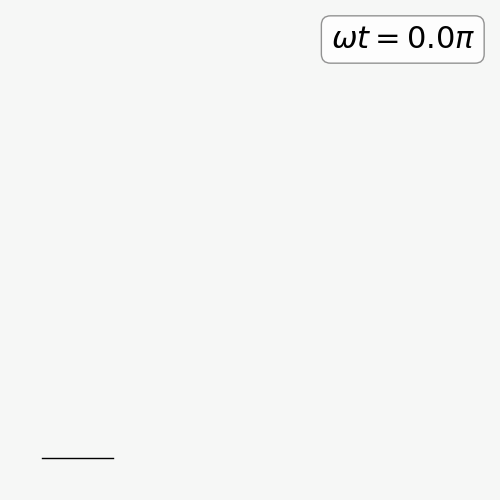

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D
import imageio_ffmpeg

# ===============================================================
# 1. PARAMETERS & INITIAL SETUPS
# ===============================================================
W, sigma1, sigma2 = 1.5, 1, -1

# 指定 MP4 匯出的目標資料夾絕對路徑
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Layout & Widgets (5x5 正方形尺寸)
fig_3 = plt.figure(figsize=(5, 5), dpi=100)

beta_slider_3 = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider_3 = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
wt_slider_3 = widgets.FloatSlider(value=0, min=0, max=2, step=2/1000, description='wt (π)')
l1_box_3, l2_box_3 = widgets.IntText(value=-1, description='l'), widgets.IntText(value=1, description="l'")

# 動態匯出控制按鈕
export_button = widgets.Button(description="匯出單一 MP4", button_style='primary', icon='video-camera')
export_all_button = widgets.Button(description="批次匯出全部 12 個 MP4", button_style='success', icon='film')
status_output = widgets.Output()

LIMIT = 0.34

# ===============================================================
# 2. UPDATE PLOT (無標題、無邊界留白、右上角 wt 顯示至小數點一位)
# ===============================================================
def update_plot_3(l1, l2, beta, alpha, wt):
    wt_rad = wt * np.pi
    beta_rad, alpha_rad = beta * np.pi, alpha * np.pi
    
    fig_3.clear()
    
    # 讓座標軸完全填滿整個 figure 畫布
    ax_int = fig_3.add_axes([0, 0, 1, 1])
    ax_int.set_aspect('equal')

    # Intensity (Longitudinal component)
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta_rad, alpha_rad, wt_rad)
    
    contour = ax_int.contourf(X, Y, I, levels=np.linspace(-LIMIT, LIMIT, 300), cmap='PRGn')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    
    # 關閉座標軸標籤與邊框
    ax_int.axis('off')
    ax_int.set_xlim(-3, 3)
    ax_int.set_ylim(-3, 3)

    # 在右上角添加 wt 文字標註 (.1f 顯示小數點一位)
    ax_int.text(0.95, 0.95, f'$\omega t = {wt:.1f}\pi$', transform=ax_int.transAxes,
                color='black', fontsize=22, fontweight='bold',
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))

# 核心動畫渲染與儲存輔助函數
def render_and_save(l1, l2, beta, alpha, file_name):
    wt_frames = np.linspace(0, 2, 100)
    
    def animate(frame_wt):
        update_plot_3(l1, l2, beta, alpha, frame_wt)
    
    anim = animation.FuncAnimation(fig_3, animate, frames=wt_frames, interval=50)
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    full_path = os.path.join(SAVE_DIR, file_name)
    
    writer = animation.FFMpegWriter(
        fps=20, 
        codec='h264', 
        bitrate=1800,
        extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2']
    )
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    anim.save(full_path, writer=writer, dpi=120, savefig_kwargs={'bbox_inches': 'tight', 'pad_inches': 0})
    return full_path

# ===============================================================
# 3. EXPORT ANIMATION FUNCTIONS (單一匯出 & 批次匯出)
# ===============================================================
def export_animation(b):
    with status_output:
        status_output.clear_output()
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR)
            
        l1, l2 = l1_box_3.value, l2_box_3.value
        beta, alpha = beta_slider_3.value, alpha_slider_3.value
        file_name = f"l_{l1}_lp_{l2}.mp4"
        
        print(f"🎬 正在渲染單一動畫: {file_name} ...")
        try:
            full_path = render_and_save(l1, l2, beta, alpha, file_name)
            print(f"✅ 匯出成功！路徑：{full_path}")
        except Exception as e:
            print(f"⚠️ 匯出失敗，錯誤訊息: {e}")

def export_all_animations(b):
    with status_output:
        status_output.clear_output()
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR)
            
        l1_list = [-1, 0, 1]
        l2_list = [-1, 0, 1, 2]
        beta = beta_slider_3.value
        alpha = alpha_slider_3.value
        
        total = len(l1_list) * len(l2_list)
        current = 0
        
        print(f"🚀 開始批次渲染全部 {total} 個影片...")
        print(f"目標資料夾：{SAVE_DIR}\n" + "-"*40)
        
        for l1 in l1_list:
            for l2 in l2_list:
                current += 1
                file_name = f"l_{l1}_lp_{l2}_longitudinal.mp4"
                print(f"[{current}/{total}] 正在渲染 {file_name} ...")
                try:
                    render_and_save(l1, l2, beta, alpha, file_name)
                except Exception as e:
                    print(f"❌ {file_name} 渲染失敗: {e}")
        
        print("-" * 40)
        print(f"🎉 全部 {total} 個 MP4 影片已順利匯出至資料夾！")

export_button.on_click(export_animation)
export_all_button.on_click(export_all_animations)

# ===============================================================
# 4. UI 聯動與顯示
# ===============================================================
out_3 = widgets.interactive_output(update_plot_3, {
    'l1': l1_box_3, 
    'l2': l2_box_3, 
    'beta': beta_slider_3, 
    'alpha': alpha_slider_3, 
    'wt': wt_slider_3
})

ui_3 = widgets.VBox([
    widgets.Label("coefficient"), 
    widgets.HBox([l1_box_3, l2_box_3]), 
    widgets.Label("parameter"), 
    widgets.HBox([beta_slider_3, alpha_slider_3, wt_slider_3]),
    widgets.HBox([export_button, export_all_button]),
    status_output
])

display(ui_3, out_3)

In [15]:
Lambda = 0.532 #um
q_0 = 2*np.pi/Lambda # um-1
w = c*q_0*10**(-6)
W = 1.5 #um
ZR = 1/2 * q_0 * (W**2) # um-1
Qc = 8.6 #um-1
print(q_0, w, ZR)

def F(phiq,q,l):
    F = (-complex(0,1))**np.abs(l)*np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    # F = np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4) 
    return F

def VVBuz(phiq,q,sigma1,sigma2,l1,l2,beta,alpha):
    
    DJ = l2-l1+sigma2-sigma1
    TJ = (l2+l1+sigma2+sigma1)/2
    
    VVBuz = np.cos((DJ*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  +  complex(0,1)*np.cos((DJ*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    # VVBuz = np.cos((DJ*phiq+alpha)/2)*(np.cos(beta/2)*F(phiq,q,l1)+np.sin(beta/2)*F(phiq,q,l2))  
    # VVBuz = complex(0,1)*np.cos((DJ*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*F(phiq,q,l1)-np.sin(beta/2)*F(phiq,q,l2))
    
    VVBuz = -1/np.sqrt(2)* (q/np.sqrt(q**2+q_0**2))*np.exp(complex(0,1)*(TJ*phiq+alpha/2)) *VVBuz
    VVBuz = np.abs(VVBuz)**2
    return VVBuz


11.810498697705988 3540.698434791077 13.286811034919236


Output()

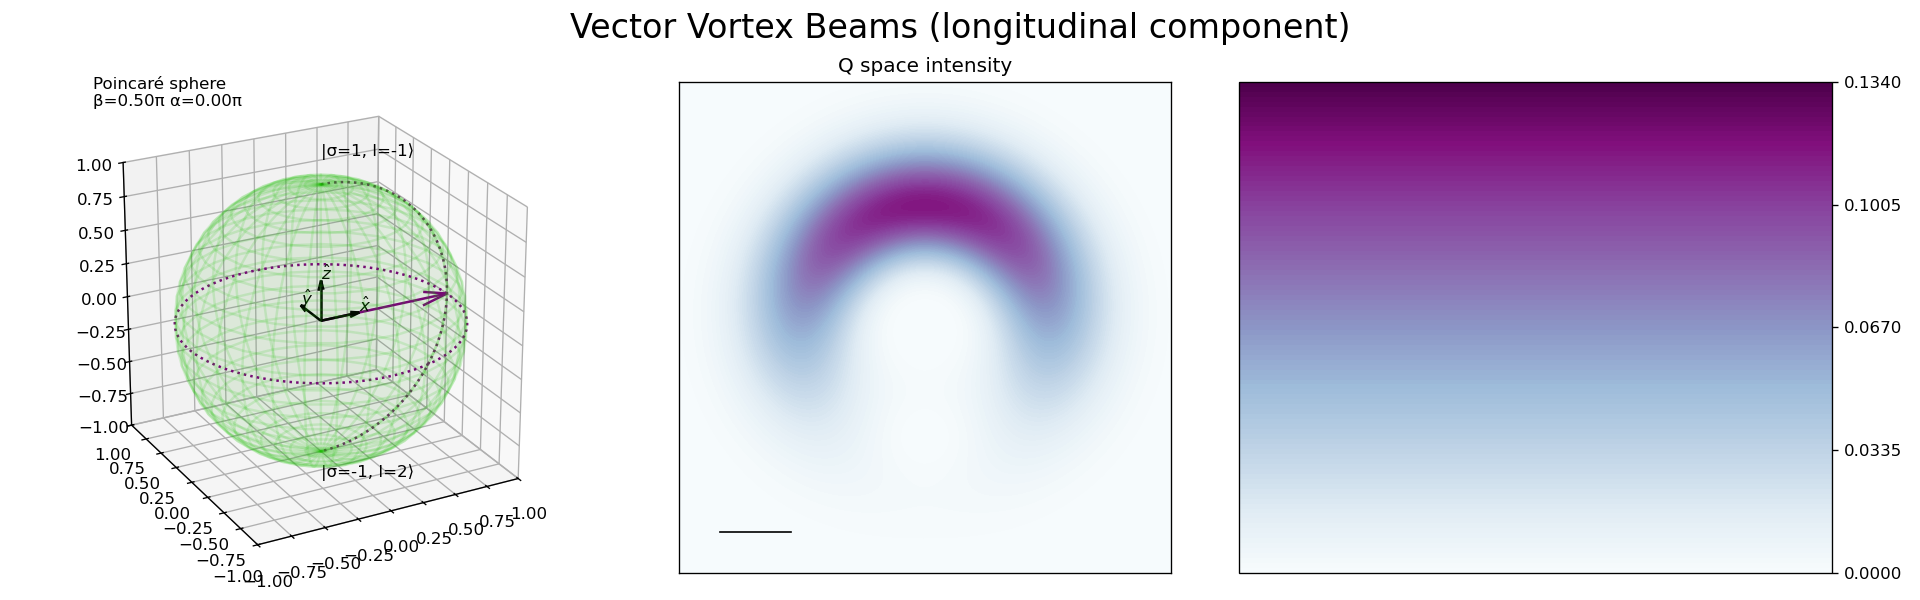

In [16]:
W, sigma1, sigma2 = 1.5, 1, -1
t = np.arange(0, 2*np.pi, 0.02)
circle, polar = np.linspace(0, 2*np.pi, 100), np.linspace(0, np.pi, 100)

# Mesh for intensity map
q, phiq = np.meshgrid(np.linspace(0.001, 6, 200), np.linspace(0, 2*np.pi, 200))
X, Y = q*np.cos(phiq), q*np.sin(phiq)

# Sphere mesh
U, V = np.mgrid[0:2*np.pi:30j, 0:np.pi:30j]
sx, sy, sz = np.cos(U)*np.sin(V), np.sin(U)*np.sin(V), np.cos(V)

# Layout & Widgets
fig = plt.figure(figsize=(16,5), dpi=120)

beta_slider = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.02, description='beta (π)')
alpha_slider = widgets.FloatSlider(value=0, min=0, max=2, step=0.02, description='alpha (π)')
l1_box, l2_box, p_box = widgets.IntText(value=-1, description='l'), widgets.IntText(value=2, description="l'"), widgets.IntText(value=0, description='p')

def update_plot(l1, l2, p, beta, alpha):
    beta, alpha = beta * np.pi, alpha * np.pi
    
    # 徹底清除舊圖記憶，防止 3D quiver 與導引圓縮放異常
    fig.clear()
    
    # 重新建立子圖 (1, 3, i)
    ax3D = fig.add_subplot(1, 3, 1, projection='3d')
    ax_int = fig.add_subplot(1, 3, 2)
    cax = fig.add_subplot(1, 3, 3)
    
    ax3D.set_aspect('equal')
    ax_int.set_aspect('equal')

    # ===================================================
    # 1. Poincaré sphere
    # ===================================================
    ax3D.plot_wireframe(sx, sy, sz, color=(0.15,0.8,0.05,0.15))
    ax3D.plot_surface(sx, sy, sz, color=(0.15,0.8,0.05,0.05))
    
    qx, qy, qz = np.cos(alpha)*np.sin(beta), np.sin(alpha)*np.sin(beta), np.cos(beta)
    
    # 標示偏振態向量，限制箭頭比例 (arrow_length_ratio)
    ax3D.quiver(0, 0, 0, qx, qy, qz, color='purple', arrow_length_ratio=0.2)
    
    # 畫出三個標準黑色坐標軸
    for mx, my, mz in [(0.3, 0, 0), (0, 0.3, 0), (0, 0, 0.3)]:
        ax3D.quiver(0, 0, 0, mx, my, mz, color='k', arrow_length_ratio=0.25)

    # 修正：使用正確的 'dotted' 純虛線樣式，無 'p' 標記
    ax3D.plot(np.sin(beta)*np.cos(circle), np.sin(beta)*np.sin(circle), np.cos(beta)+0*circle, linestyle='dotted', color='purple')
    ax3D.plot(np.sin(polar)*np.cos(alpha), np.sin(polar)*np.sin(alpha), np.cos(polar), linestyle='dotted', color='purple')

    ax3D.text2D(0.05, 0.95, f'Poincaré sphere\nβ={beta/np.pi:.2f}π α={alpha/np.pi:.2f}π', transform=ax3D.transAxes)
    for txt, (mx, my, mz) in {r'$\hat{x}$':(0.3,0,0), r'$\hat{y}$':(0,0.3,0), r'$\hat{z}$':(0,0,0.3)}.items(): ax3D.text(mx, my, mz, txt)
    ax3D.text(0, 0, 1.2, f'|σ={sigma1}, l={l1}⟩'); ax3D.text(0, 0, -1.2, f'|σ={sigma2}, l={l2}⟩')
    ax3D.set_xlim(-1,1); ax3D.set_ylim(-1,1); ax3D.set_zlim(-1,1); ax3D.view_init(24, -118)

    # ===================================================
    # 2. Intensity (Longitudinal component: VVBuz, Blues 色階)
    # ===================================================
    I = VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha)
    
    TJ = (l2+l1+sigma2+sigma1)/2
    print('TJ=',TJ)

    contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.134, 100), cmap='BuPu')
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.134, 100), cmap='YlGn')
    # contour = ax_int.contourf(X, Y, I, levels=np.linspace(0, 0.0067, 100), cmap='PuRd')
    ax_int.add_line(Line2D(np.linspace(-2.5, -2.5+0.86, 50), np.linspace(-2.5, -2.5, 50), linewidth=1, color='black'))
    ax_int.set_title("Q space intensity"); ax_int.set_xticks([]); ax_int.set_yticks([]); ax_int.set_xlim(-3,3); ax_int.set_ylim(-3,3)

    plt.colorbar(contour, cax=cax, ticks=np.linspace(0, 0.134, 5))
    
    plt.suptitle("Vector Vortex Beams (longitudinal component)", fontsize=20)
    plt.tight_layout()
    print(f'alpha={alpha/np.pi:.3f}π   beta={beta/np.pi:.3f}π')

out = widgets.interactive_output(update_plot, {'l1':l1_box, 'l2':l2_box, 'p':p_box, 'beta':beta_slider, 'alpha':alpha_slider})
ui = widgets.VBox([widgets.Label("coefficient"), widgets.HBox([l1_box, l2_box, p_box]), widgets.Label("parameter"), widgets.HBox([beta_slider, alpha_slider])])
display(ui, out)

In [17]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.animation as animation
import imageio_ffmpeg
import ipywidgets as widgets
from ipywidgets import FloatSlider, Output, Button, VBox, HBox
from IPython.display import display

# ===============================================================
# 1. PARAMETERS & DIRECTORY SETUP
# ===============================================================
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"

# 🎯 將 height_ratios 改為 [2, 1, 2]
fig, axes = plt.subplots(
    3, 1, 
    figsize=(10, 6.8), 
    sharex=True, 
    dpi=125,
    gridspec_kw={'height_ratios': [2, 1, 2]}
)

x = np.linspace(0, 2 * np.pi, 1000)

# axes[0]: Complex Amplitude / Envelope
line_env_top, = axes[0].plot(x, np.zeros_like(x), color='crimson', linestyle='-', linewidth=2, label='Envelope (+)')
line_env_bot, = axes[0].plot(x, np.zeros_like(x), color='crimson', linestyle='-', linewidth=2, alpha=0.7)

# axes[1]: Carrier Wave
line_carrier, = axes[1].plot(x, np.zeros_like(x), linewidth=2, color='royalblue')

# axes[2]: Sum Wave
line_sum, = axes[2].plot(x, np.zeros_like(x), linewidth=1, color='purple')
env_top_sum, = axes[2].plot(x, np.zeros_like(x), color='black', linestyle='--', linewidth=1.5, alpha=0.5)
env_bot_sum, = axes[2].plot(x, np.zeros_like(x), color='black', linestyle='--', linewidth=1.5, alpha=0.5)

# 右上角 wt 數值標示
wt_text = axes[0].text(
    0.98, 0.88, '', transform=axes[0].transAxes, 
    ha='right', va='top', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.85)
)

def format_pi(val, pos):
    frac = val / np.pi
    if np.isclose(frac, 0):
        return "$0$"
    elif np.isclose(frac, 1):
        return r"$\pi$"
    elif np.isclose(frac, -1):
        return r"$-\pi$"
    elif np.isclose(frac % 1, 0):
        return rf"${int(frac)}\pi$"
    else:
        return rf"${frac:.2f}\pi$"

for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_pi))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.pi / 3))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='x', which='minor', length=4, color='black')
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.grid(False, which='minor')

axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)
axes[2].tick_params(labelbottom=True)

axes[0].set_xlim(0, 2 * np.pi)
axes[0].set_ylabel("Envelope", fontsize=10)
axes[1].set_ylabel("Carrier", fontsize=10)
axes[2].set_ylabel("Sum Wave", fontsize=10)

plt.tight_layout()
plt.close(fig)

out = Output()
status_output = Output()

# ===============================================================
# 2. UPDATE PLOT DATA & INTERACTIVE FUNCTION
# ===============================================================
def update_plot_data(k1, k2, abs_A1, phi1, abs_A2, phi2, C, wt):
    wt_val = wt * np.pi
    phi1_val = phi1 * np.pi
    phi2_val = phi2 * np.pi
    C_val = C * np.pi
    
    delta_k = k2 - k1
    c_prime = C_val + phi2_val - phi1_val
    
    G_plus = (abs_A1 + abs_A2)
    G_minus = (abs_A1 - abs_A2)
    theta = (delta_k * x + c_prime) / 2.0
    envelope = np.abs((G_plus * np.cos(theta)) - (1j) * (G_minus * np.sin(theta)))
    
    k_avg = (k1 + k2) / 2.0
    carrier_phase = k_avg * x - wt_val + (c_prime / 2.0) + phi1_val
    carrier = np.cos(carrier_phase)
    
    y1 = abs_A1 * np.cos(k1 * x - wt_val + phi1_val)
    y2 = abs_A2 * np.cos(k2 * x - wt_val + phi2_val + C_val)
    y_sum = y1 + y2
    
    line_env_top.set_ydata(envelope)
    line_env_bot.set_ydata(-envelope)
    line_carrier.set_ydata(carrier)
    line_sum.set_ydata(y_sum)
    env_top_sum.set_ydata(envelope)
    env_bot_sum.set_ydata(-envelope)

    # 🎯 wt 顯示至小數點一位 (.1f)
    wt_text.set_text(rf"$\omega t = {wt:.1f}\pi$")

    max_env = np.max(G_plus)
    axes[0].set_ylim(-2, 2)
    axes[0].yaxis.set_major_locator(ticker.MultipleLocator(1))
    axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f' if max_env <= 2 else '%d'))

    axes[1].set_ylim(-1, 1)
    axes[1].yaxis.set_major_locator(ticker.MultipleLocator(1))
    axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

    axes[2].set_ylim(-2, 2)
    axes[2].yaxis.set_major_locator(ticker.MultipleLocator(1))
    axes[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

def update_plot(k1=5.0, k2=4.0, abs_A1=1.0, phi1=-0.5, abs_A2=1.0, phi2=-1.0, C=0.0, wt=0.0):
    update_plot_data(k1, k2, abs_A1, phi1, abs_A2, phi2, C, wt)
    with out:
        out.clear_output(wait=True)
        display(fig)

# ===============================================================
# 3. RENDER & SAVE FUNCTION (完全參考範例模式)
# ===============================================================
def render_and_save(k1, k2, abs_A1, phi1, abs_A2, phi2, C, file_name):
    wt_frames = np.linspace(0, 2, 100)
    
    def animate(frame_wt):
        update_plot_data(k1, k2, abs_A1, phi1, abs_A2, phi2, C, frame_wt)
    
    anim = animation.FuncAnimation(fig, animate, frames=wt_frames, interval=50)
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    
    full_path = os.path.join(SAVE_DIR, file_name)
    
    writer = animation.FFMpegWriter(
        fps=20, 
        codec='h264', 
        bitrate=1800,
        extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2']
    )
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    anim.save(full_path, writer=writer, dpi=125, savefig_kwargs={'bbox_inches': 'tight'})
    return full_path

# ===============================================================
# 4. UI CONTROLS & EXPORT ACTIONS
# ===============================================================
slider_k1 = FloatSlider(min=-7, max=7, step=1, value=5, description="k:")
slider_k2 = FloatSlider(min=-7, max=7, step=1, value=4, description="k':")
slider_abs_A1 = FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description="|A|:")
slider_phi1 = FloatSlider(min=-2, max=2, step=0.1, value=0, description="Arg[A](pi):")
slider_abs_A2 = FloatSlider(min=0.1, max=2.0, step=0.1, value=0.9, description="|A'|:")
slider_phi2 = FloatSlider(min=-2, max=2, step=0.1, value=0, description="Arg[A'](pi):")
slider_C = FloatSlider(min=-1, max=2, step=0.05, value=0.0, description="C:")
slider_wt = FloatSlider(min=0.0, max=2.0, step=0.02, value=0.0, description="wt:")

btn_play = Button(description="▶ 播放動畫 (0 ~ 2π)", button_style='success', icon='play')
btn_export = Button(description="匯出單一 MP4", button_style='primary', icon='video-camera')

def play_animation(b):
    btn_play.disabled = True
    btn_export.disabled = True
    for val in np.linspace(0, 2.0, 101):
        slider_wt.value = round(val, 1)
        time.sleep(0.02)
    btn_play.disabled = False
    btn_export.disabled = False

def export_animation(b):
    btn_play.disabled = True
    btn_export.disabled = True
    
    with status_output:
        status_output.clear_output()
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR)
            
        file_name = f"wave_k_{int(slider_k1.value)}_kp_{int(slider_k2.value)}.mp4"
        print(f"🎬 正在渲染單一動畫: {file_name} ...")
        
        try:
            full_path = render_and_save(
                slider_k1.value, slider_k2.value,
                slider_abs_A1.value, slider_phi1.value,
                slider_abs_A2.value, slider_phi2.value,
                slider_C.value, file_name
            )
            print(f"✅ 匯出成功！路徑：{full_path}")
        except Exception as e:
            print(f"⚠️ 匯出失敗，錯誤訊息: {e}")
            
    btn_play.disabled = False
    btn_export.disabled = False

btn_play.on_click(play_animation)
btn_export.on_click(export_animation)

# UI 排版組裝
ui_controls = VBox([
    slider_k1, slider_k2, slider_abs_A1, slider_phi1, 
    slider_abs_A2, slider_phi2, slider_C, slider_wt, 
    HBox([btn_play, btn_export]),
    status_output
])

interactive_plot = widgets.interactive_output(
    update_plot,
    {
        'k1': slider_k1, 'k2': slider_k2, 'abs_A1': slider_abs_A1, 'phi1': slider_phi1,
        'abs_A2': slider_abs_A2, 'phi2': slider_phi2, 'C': slider_C, 'wt': slider_wt
    }
)

display(ui_controls, out)

Output()

In [5]:
import numpy as np
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ===============================================================
# 獨立 COLORMAPS 設定區塊
# ===============================================================
ncolors = 1001  # 用奇數可以讓雙極性的 0.0 完美落在正中間的那點

# --- 【雙極性專用】數值範圍從 -1 到 1，值為 0 時是黑色 ---
ncolor_div = np.linspace(-1, 1, ncolors)
pos_mask = ncolor_div >= 0
neg_mask = ncolor_div < 0

factor_pos = ncolor_div[pos_mask]**1.5
factor_neg = np.abs(ncolor_div[neg_mask])**1.5

# 雙極性的對稱透明度 A_div
A_div = -0.015 * np.log(np.abs(ncolor_div) + 0.02) + 0.9
A_div = np.clip(A_div, 0.0, 1.0)


# --- 【單向性專用：3 (B)】數值範圍從 0 到 1，維持原本從白出發 ---
ncolor_seq = np.linspace(0, 1, ncolors)
A_seq = np.clip(-0.015 * np.log(ncolor_seq + 0.02) + 0.9, 0.0, 1.0)


# ===============================================================
# 建立與配置各組 Colormap 的顏色矩陣 (0=R, 1=G, 2=B)
# ===============================================================

def create_div_array(pos_rgb, neg_rgb):
    """輔助函式：快速生成雙極性且中間為黑的 RGBA 矩陣"""
    arr = np.zeros((ncolors, 4))
    arr[:, 3] = A_div
    arr[pos_mask, 0] = factor_pos * pos_rgb[0]
    arr[pos_mask, 1] = factor_pos * pos_rgb[1]
    arr[pos_mask, 2] = factor_pos * pos_rgb[2]
    arr[neg_mask, 0] = factor_neg * neg_rgb[0]
    arr[neg_mask, 1] = factor_neg * neg_rgb[1]
    arr[neg_mask, 2] = factor_neg * neg_rgb[2]
    return arr

# ---------------------------------------------------------------
# 🎯【實部新設】改為高明度、柔和馬卡龍色系（粉色端）
# ---------------------------------------------------------------
# 1. BP：上【淺紅 / 櫻花粉】下【淺青綠 / 蒂芬妮藍綠】
# 淺紅增加綠藍光調高明度 [1.0, 0.5, 0.5]；互補淺青綠為 [0.4, 0.9, 0.8]
color_arrayBP = create_div_array([1.0, 0.5, 0.5], [0.4, 0.9, 0.8])

# 2. BM：上【淺藍 / 天空藍】下【淺粉橘 / 柔砂橘】
# 淺藍調配為 [0.5, 0.75, 1.0]；互補淺粉橘為 [1.0, 0.65, 0.4]
color_arrayBM = create_div_array([0.5, 0.75, 1.0], [1.0, 0.65, 0.4])

# 3. B：完全不變 (單向從白到綠，雖然目前沒畫，仍保留不刪)
color_arrayB = np.ones((ncolors, 4))
color_arrayB[:, 0] = 1.0 - (ncolor_seq**1.5)
color_arrayB[:, 2] = 1.0 - (ncolor_seq**1.5)
color_arrayB[:, 3] = A_seq

# 4. G：上黃下紫 (實部第三個 row)
color_arrayG = create_div_array([1.0, 1.0, 0.0], [0.5, 0.0, 0.5])


# ---------------------------------------------------------------
# 🎯【虛部維持】濃郁、深沉寶石色系
# ---------------------------------------------------------------
# 5. BP_Imag：上【濃郁嫣紅(洋紅)】下【薄荷淺綠】
color_arrayBP_Imag = create_div_array([1.0, 0.2, 0.6], [0.3, 1.0, 0.6])

# 6. BM_Imag：上【午夜深藍】下【飽和金黃】
color_arrayBM_Imag = create_div_array([0.0, 0.1, 0.5], [1.0, 0.75, 0.0])

# 7. G_Imag：上淺藍下橘紅
color_arrayG_Imag = create_div_array([0.4, 0.8, 1.0], [1.0, 0.2, 0.0])


# ===============================================================
# 註冊所有 Colormap 物件到系統中
# ===============================================================
cmaps_to_register = {
    'white_2colorbarBP': color_arrayBP,
    'white_2colorbarBM': color_arrayBM,
    'white_2colorbarB':  color_arrayB,
    'white_2colorbarG':  color_arrayG,
    'white_2colorbarBP_Imag': color_arrayBP_Imag,  
    'white_2colorbarBM_Imag': color_arrayBM_Imag,  
    'white_2colorbarG_Imag':  color_arrayG_Imag   
}

for name, arr in cmaps_to_register.items():
    map_obj = LinearSegmentedColormap.from_list(name=name, colors=arr)
    mpl.colormaps.register(cmap=map_obj, force=True)

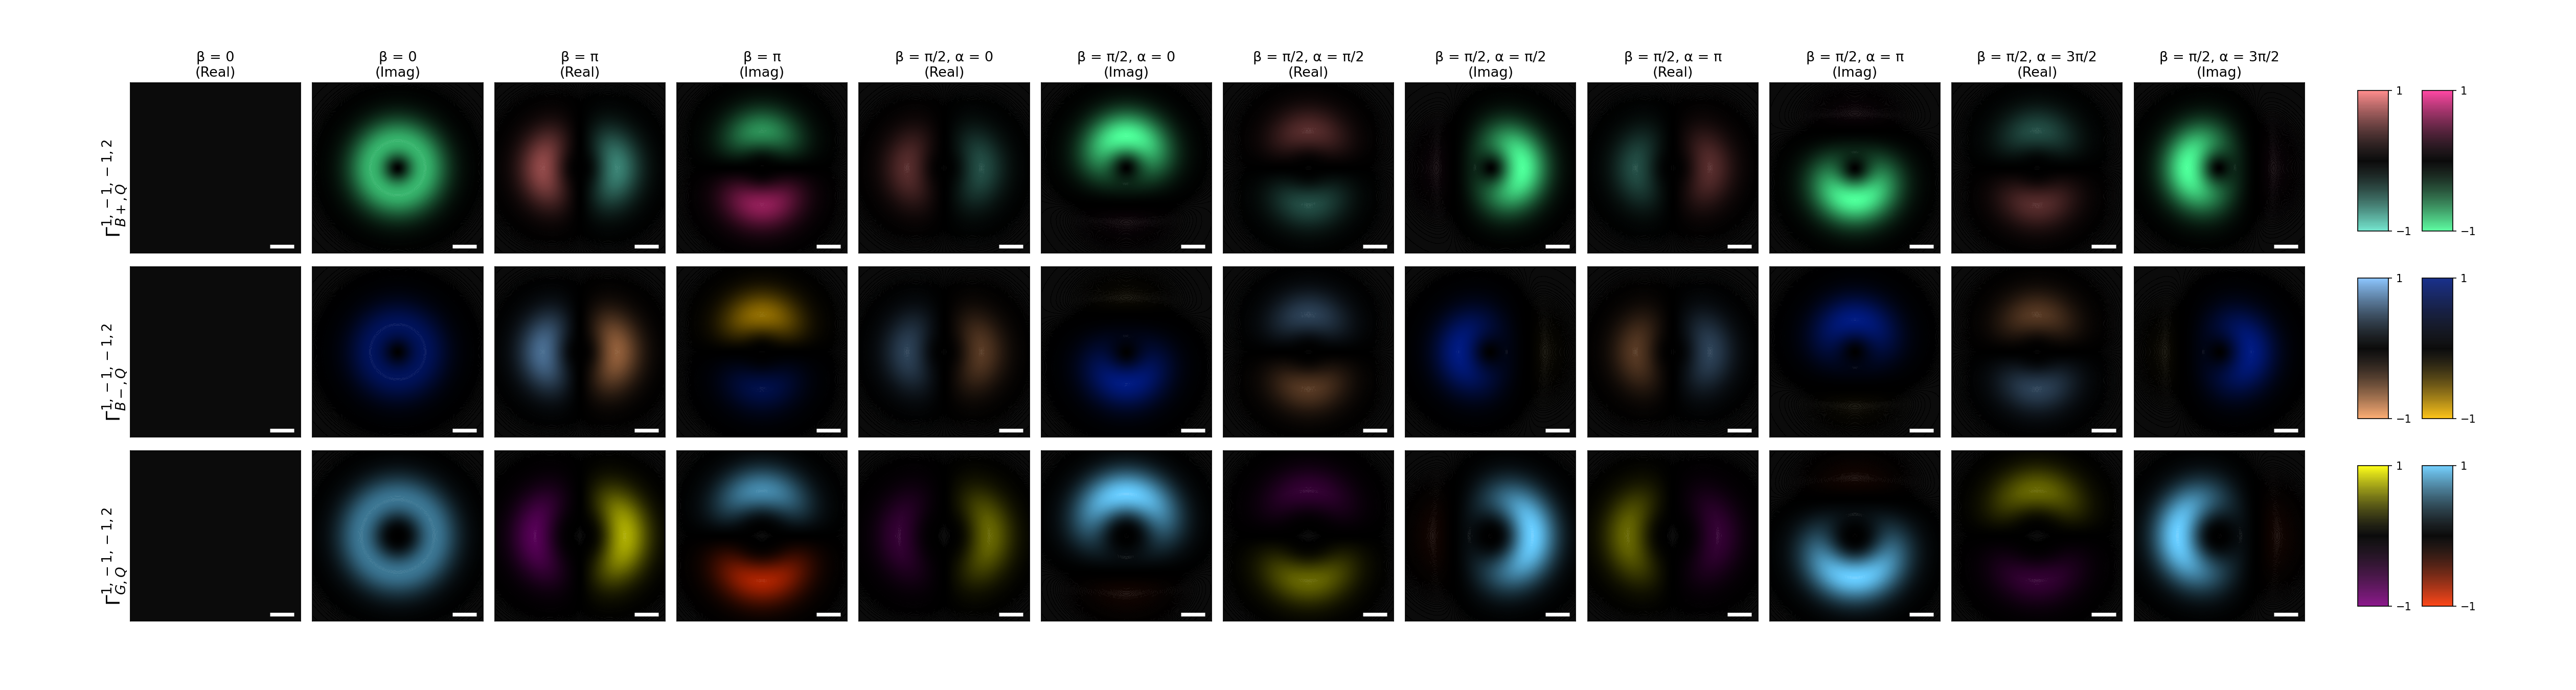

In [6]:
# ===============================================================
# 🎯 CASE 參數設定區 (要在最頂層修改不同 Case 請改這裡)
# ===============================================================
sigma1 = 1
sigma2 = -1
l1 = -1
l2 = 2

# ===============================================================
# 2. PARAMETERS & GRID SETUP
# ===============================================================
betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi/2], [np.pi/2, np.pi], [np.pi/2, 3*np.pi/2]])
EX = ['B+', 'B-', 'G']  

# 實部與虛部的 Colormap 名稱清單串接
cmaps_real = ['white_2colorbarBP', 'white_2colorbarBM', 'white_2colorbarG']
cmaps_imag = ['white_2colorbarBP_Imag', 'white_2colorbarBM_Imag', 'white_2colorbarG_Imag']

# 🎯 欄數一樣加倍，但佈局改變：總共 12 欄 (每個角度組合佔用連續的 2 欄)
fig, ax = plt.subplots(len(EX), len(betalpha) * 2, figsize=(2.8 * len(betalpha) * 2, 3 * len(EX)), dpi=150)

# Q-space 網格建立 (確保 W, Q_c, q_0 已在環境中定義)
Q, phiQ = np.meshgrid(np.linspace(0.0001, 1.2*Q_c, 101), np.linspace(0, 2*np.pi, 101))
X, Y = Q*np.cos(phiQ), Q*np.sin(phiQ)

# ===============================================================
# 3. PHYSICS FUNCTIONS
# ===============================================================
def F(phiq, q, l):
    return (-1j)**np.abs(l) * np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4)

def VVB_u(phiq, q, beta, alpha):
    f1, f2 = F(phiq, q, l1) * np.exp(1j*l1*phiq), F(phiq, q, l2) * np.exp(1j*l2*phiq)
    ux = (np.cos(beta/2)*f1 + np.exp(1j*alpha)*np.sin(beta/2)*f2) / np.sqrt(2)
    uy = 1j * (sigma1*np.cos(beta/2)*f1 + sigma2*np.exp(1j*alpha)*np.sin(beta/2)*f2) / np.sqrt(2)
    return ux, uy

def VVBuz(phiq, q, beta, alpha):
    DJ = l2 - l1 + sigma2 - sigma1
    TJ = (l2 + l1 + sigma2 + sigma1) / 2
    f1, f2 = F(phiq, q, l1), F(phiq, q, l2)  
    VVBuz_val = np.cos((DJ*phiq+alpha)/2)*(np.cos(beta/2)*f1 + np.sin(beta/2)*f2) + 1j*np.cos((DJ*phiq+alpha+np.pi)/2)*(np.cos(beta/2)*f1 - np.sin(beta/2)*f2)
    return -1/np.sqrt(2) * (q/np.sqrt(q**2+q_0**2)) * np.exp(1j*(TJ*phiq+alpha/2)) * VVBuz_val

def gamma_map_complex(ex, beta, alpha):
    ux, uy = VVB_u(phiQ, Q, beta, alpha)
    if ex == 0: return ux * np.cos(phiQ) + uy * np.sin(phiQ)
    if ex == 1: return ux * (-1j)*np.sin(phiQ) + uy * 1j*np.cos(phiQ)
    if ex == 2: return VVBuz(phiQ, Q, beta, alpha)

# ===============================================================
# 4. MAIN PLOTTING LOOP (交錯並排交替核心)
# ===============================================================
for ex in range(len(EX)):
    complex_maps = [np.nan_to_num(gamma_map_complex(ex, b, a), nan=0.0) for b, a in betalpha]
    
    row_max = max(max(np.max(np.abs(np.real(Z))), np.max(np.abs(np.imag(Z)))) for Z in complex_maps)
    row_max = 1.0 if (not np.isfinite(row_max) or row_max < 1e-14) else row_max

    for col in range(len(betalpha)):
        Z_complex = complex_maps[col]
        
        # 🎯【核心修改】計算當前角度組合對應的子圖欄位索引
        idx_real = col * 2      # 0, 2, 4, 6, 8, 10
        idx_imag = col * 2 + 1  # 1, 3, 5, 7, 9, 11
        
        # ---- 畫實部 (左邊那格) ----
        ax_real = ax[ex, idx_real]
        Zplot_real = np.real(Z_complex) / row_max
        ax_real.contourf(X, Y, Zplot_real, levels=np.linspace(-1, 1, 1000), vmin=-1, vmax=1, cmap=cmaps_real[ex])
        ax_real.hlines(-0.46*Q_c/np.sqrt(2), 0.32*Q_c/np.sqrt(2), 0.32*Q_c/np.sqrt(2)+0.1*Q_c, color="w", linewidth=3.5, zorder=2)
        
        # ---- 畫虛部 (右邊相鄰那格) ----
        ax_imag = ax[ex, idx_imag]  
        Zplot_imag = np.imag(Z_complex) / row_max
        ax_imag.contourf(X, Y, Zplot_imag, levels=np.linspace(-1, 1, 1000), vmin=-1, vmax=1, cmap=cmaps_imag[ex])
        ax_imag.hlines(-0.46*Q_c/np.sqrt(2), 0.32*Q_c/np.sqrt(2), 0.32*Q_c/np.sqrt(2)+0.1*Q_c, color="w", linewidth=3.5, zorder=2)

        for ax_obj in [ax_real, ax_imag]:
            ax_obj.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
            ax_obj.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
            ax_obj.set_xticks([]); ax_obj.set_yticks([])
            ax_obj.set_aspect("equal")

# ===============================================================
# 5. LABELS & COLORBARS 
# ===============================================================
# 設定標題：讓同一組角度的 Real 與 Imag 各自標記在對應的上方
base_titles = ['β = 0', 'β = π', 'β = π/2, α = 0', 'β = π/2, α = π/2', 'β = π/2, α = π', 'β = π/2, α = 3π/2']
for i, title in enumerate(base_titles):
    ax[0, i * 2].set_title(title + "\n(Real)", fontsize=13)                     
    ax[0, i * 2 + 1].set_title(title + "\n(Imag)", fontsize=13)     

coeff = f'{sigma1}, {l1}, {sigma2}, {l2}'
labels = [rf'$\Gamma_{{B+,Q}}^{{{coeff}}}$', rf'$\Gamma_{{B-,Q}}^{{{coeff}}}$', rf'$\Gamma_{{G,Q}}^{{{coeff}}}$']
for ex in range(len(EX)):
    ax[ex, 0].text(-4.1, -2.2, labels[ex], fontsize=18, rotation=90)

# 雙 Colorbar 機制 (維持放置於最右側)
for ex in range(len(EX)):
    pos = ax[ex, -1].get_position()
    
    # 1. 放置左邊的實部 Colorbar
    cax_real = fig.add_axes([0.915, pos.y0, 0.012, pos.height])  
    map_real = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=-1, vmax=1), cmap=cmaps_real[ex])
    fig.colorbar(map_real, cax=cax_real, ticks=[-1, 1], format="{x:.0f}")
    
    # 2. 放置右邊的虛部 Colorbar
    cax_imag = fig.add_axes([0.940, pos.y0, 0.012, pos.height])  
    map_imag = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=-1, vmax=1), cmap=cmaps_imag[ex])
    fig.colorbar(map_imag, cax=cax_imag, ticks=[-1, 1], format="{x:.0f}")

fig.subplots_adjust(left=0.05, bottom=0.10, right=0.895, top=0.88, wspace=0.05, hspace=0.08)
plt.show()

In [7]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
import ipywidgets as widgets
from ipywidgets import FloatSlider, IntSlider, Output, Button, VBox, HBox, interactive_output
from IPython.display import display

# ===============================================================
# 1. PARAMETERS & DIRECTORY SETUP
# ===============================================================
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"
cmap_real_name = 'white_2colorbarG'

# 網格建立 (預設補齊機制)
if 'W' not in globals(): W = 1.0
if 'Q_c' not in globals(): Q_c = 5.0
if 'q_0' not in globals(): q_0 = 1.0
if 'Factorial' not in globals(): 
    from math import factorial as Factorial

Q, phiQ = np.meshgrid(np.linspace(0.0001, 1.2*Q_c, 101), np.linspace(0, 2*np.pi, 101))
X, Y = Q*np.cos(phiQ), Q*np.sin(phiQ)

# ===============================================================
# 2. PHYSICS FUNCTIONS (修正相位與振幅結構)
# ===============================================================
def F(phiq, q, l):
    return (-1j)**np.abs(l) * np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4)

def VVBuz(phiq, q, sigma1, sigma2, l1, l2, beta, alpha, wt):
    DJ = l2 - l1 + sigma2 - sigma1
    TJ = (l2 + l1 + sigma2 + sigma1) / 2.0
    
    f1, f2 = F(phiq, q, l1), F(phiq, q, l2)  
    
    # 保持複數連續振幅
    term_real = np.cos((DJ*phiq + alpha)/2.0) * (np.cos(beta/2.0)*f1 + np.sin(beta/2.0)*f2)
    term_imag = np.cos((DJ*phiq + alpha + np.pi)/2.0) * (np.cos(beta/2.0)*f1 - np.sin(beta/2.0)*f2)
    VVBuz_val = term_real + 1j * term_imag
    
    # 結合全域相位因子與時間演化項 exp(-i * wt)
    radial_factor = -1.0 / np.sqrt(2.0) * (q / np.sqrt(q**2 + q_0**2))
    phase_factor = np.exp(1j * (TJ * phiq + alpha / 2.0 - wt))
    
    return radial_factor * phase_factor * VVBuz_val

def gamma_map_complex_G(sigma1, sigma2, l1, l2, beta, alpha, wt):
    return VVBuz(phiQ, Q, sigma1, sigma2, l1, l2, beta, alpha, wt)

# ===============================================================
# 3. INTERACTIVE PLOTTING & UI SETUP (固定全局最大值)
# ===============================================================
fig, ax_real = plt.subplots(1, 1, figsize=(4.5, 4.5), dpi=130)

out = Output()
status_output = Output()

def get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi):
    """計算跨越時間週期 (wt in [0, 2pi]) 的空間最大值，防止動畫過程中的動態縮放失真"""
    wt_samples = np.linspace(0, 2*np.pi, 20)
    beta = beta_pi * np.pi
    alpha = alpha_pi * np.pi
    
    max_val = 0.0
    for wt in wt_samples:
        Z = np.nan_to_num(gamma_map_complex_G(sigma1, sigma2, l1, l2, beta, alpha, wt), nan=0.0)
        max_val = max(max_val, np.max(np.abs(np.real(Z))))
        
    return 1.0 if (max_val < 1e-14 or not np.isfinite(max_val)) else max_val

def update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, wt_pi, global_max=None):
    beta = beta_pi * np.pi
    alpha = alpha_pi * np.pi
    wt = wt_pi * np.pi
    
    Z_complex = np.nan_to_num(gamma_map_complex_G(sigma1, sigma2, l1, l2, beta, alpha, wt), nan=0.0)
    
    # 🎯 使用固定最大值進行正規化，確保時間動態波形的連續性
    if global_max is None:
        global_max = get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi)
        
    Zplot_real = np.real(Z_complex) / global_max
    
    ax_real.clear()
    ax_real.contourf(X, Y, Zplot_real, levels=np.linspace(-1, 1, 300), vmin=-1, vmax=1, cmap=cmap_real_name)
    
    # 左下角比例尺
    ax_real.hlines(-0.42*Q_c/np.sqrt(2), -0.42*Q_c/np.sqrt(2), -0.42*Q_c/np.sqrt(2)+0.1*Q_c, color="w", linewidth=3.5, zorder=2)
    
    # 右上角 wt 標註
    ax_real.text(0.95, 0.95, f'$\omega t = {wt_pi:.1f}\pi$', transform=ax_real.transAxes,
                color='black', fontsize=22, fontweight='bold', ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax_real.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    ax_real.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    ax_real.set_aspect("equal")
    
    # 完全去除座標軸與周圍白邊
    ax_real.axis('off')
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

def update_plot(sigma1=1, sigma2=-1, l1=-1, l2=2, beta_pi=0.5, alpha_pi=0.0, wt_pi=0.0):
    update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, wt_pi)
    with out:
        out.clear_output(wait=True)
        display(fig)

plt.close(fig)

# ===============================================================
# 4. EXPORT ANIMATION FUNCTION
# ===============================================================
def render_and_save(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, file_name):
    wt_frames = np.linspace(0, 2, 100)
    
    # 預先算好該組參數的全時間域最大值
    g_max = get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi)
    
    def animate(frame_wt):
        update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, frame_wt, global_max=g_max)
    
    anim = animation.FuncAnimation(fig, animate, frames=wt_frames, interval=50)
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    
    full_path = os.path.join(SAVE_DIR, file_name)
    
    writer = animation.FFMpegWriter(
        fps=20, 
        codec='h264', 
        bitrate=1800,
        extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2']
    )
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    anim.save(full_path, writer=writer, dpi=130, savefig_kwargs={'bbox_inches': 'tight', 'pad_inches': 0})
    return full_path

# ===============================================================
# 5. CONTROLS & BATCH EXPORT ACTIONS
# ===============================================================
slider_sigma1 = IntSlider(value=1, min=-2, max=2, step=1, description=r'$\sigma_1$:')
slider_sigma2 = IntSlider(value=-1, min=-2, max=2, step=1, description=r'$\sigma_2$:')
slider_l1 = IntSlider(value=-1, min=-5, max=5, step=1, description=r'$l_1$:')
slider_l2 = IntSlider(value=2, min=-5, max=5, step=1, description=r'$l_2$:')

slider_beta = FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, description=r'$\beta (\pi):$')
slider_alpha = FloatSlider(value=0.0, min=0.0, max=2.0, step=0.02, description=r'$\alpha (\pi):$')
slider_wt = FloatSlider(value=0.0, min=0.0, max=2.0, step=0.02, description=r'$\omega t (\pi):$')

btn_export_batch = Button(description="🎬 批次匯出動畫 (l1=-1,0 & l2=0,1,2)", button_style='primary', icon='video-camera', layout=widgets.Layout(width='320px'))

def export_batch_animation(b):
    btn_export_batch.disabled = True
    
    with status_output:
        status_output.clear_output()
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR)
            
        l1_list = [-1, 0]
        l2_list = [0, 1, 2]
        total_tasks = len(l1_list) * len(l2_list)
        count = 1
        
        print(f"🚀 開始批次匯出 {total_tasks} 個 MP4 動畫至: {SAVE_DIR}\n" + "="*50)
        
        s1 = slider_sigma1.value
        s2 = slider_sigma2.value
        b_val = slider_beta.value
        a_val = slider_alpha.value
        
        for cur_l1 in l1_list:
            for cur_l2 in l2_list:
                file_name = f"gray_l1_{cur_l1}_l2_{cur_l2}.mp4"
                print(f"[{count}/{total_tasks}] 正在渲染: {file_name} ...")
                try:
                    full_path = render_and_save(s1, s2, cur_l1, cur_l2, b_val, a_val, file_name)
                    print(f"    ✅ 完成！")
                except Exception as e:
                    print(f"    ⚠️ 失敗: {e}")
                count += 1
                
        print("="*50 + "\n🎉 批次匯出結束！")
        
    btn_export_batch.disabled = False

btn_export_batch.on_click(export_batch_animation)

interactive_plot = interactive_output(
    update_plot, 
    {
        'sigma1': slider_sigma1, 'sigma2': slider_sigma2,
        'l1': slider_l1, 'l2': slider_l2,
        'beta_pi': slider_beta, 'alpha_pi': slider_alpha, 'wt_pi': slider_wt
    }
)

ui = VBox([
    HBox([slider_sigma1, slider_sigma2]),
    HBox([slider_l1, slider_l2]),
    HBox([slider_beta, slider_alpha, slider_wt]),
    HBox([btn_export_batch]),
    status_output,
    out
])

display(ui)

In [8]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
import ipywidgets as widgets
from ipywidgets import FloatSlider, IntSlider, Output, Button, VBox, HBox, interactive_output
from IPython.display import display

# ===============================================================
# 1. PARAMETERS & DIRECTORY SETUP
# ===============================================================
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"
cmap_real_name = 'white_2colorbarBP'  # EX = 0 使用 BP 顏色對應

# 網格建立 (預設補齊機制)
if 'W' not in globals(): W = 1.0
if 'Q_c' not in globals(): Q_c = 5.0
if 'q_0' not in globals(): q_0 = 1.0
if 'Factorial' not in globals(): 
    from math import factorial as Factorial

Q, phiQ = np.meshgrid(np.linspace(0.0001, 1.2*Q_c, 101), np.linspace(0, 2*np.pi, 101))
X, Y = Q*np.cos(phiQ), Q*np.sin(phiQ)

# ===============================================================
# 2. PHYSICS FUNCTIONS (EX = 0 專用)
# ===============================================================
def F(phiq, q, l):
    return (-1j)**np.abs(l) * np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4)

def VVB_u(phiq, q, sigma1, sigma2, l1, l2, beta, alpha):
    f1, f2 = F(phiq, q, l1) * np.exp(1j*l1*phiq), F(phiq, q, l2) * np.exp(1j*l2*phiq)
    ux = (np.cos(beta/2.0)*f1 + np.exp(1j*alpha)*np.sin(beta/2.0)*f2) / np.sqrt(2.0)
    uy = 1j * (sigma1*np.cos(beta/2.0)*f1 + sigma2*np.exp(1j*alpha)*np.sin(beta/2.0)*f2) / np.sqrt(2.0)
    return ux, uy

def gamma_map_complex_BP(sigma1, sigma2, l1, l2, beta, alpha, wt):
    ux, uy = VVB_u(phiQ, Q, sigma1, sigma2, l1, l2, beta, alpha)
    field = ux * np.cos(phiQ) + uy * np.sin(phiQ)
    return field * np.exp(-1j * wt)

# ===============================================================
# 3. INTERACTIVE PLOTTING & UI SETUP (固定全時域最大值)
# ===============================================================
fig, ax_real = plt.subplots(1, 1, figsize=(4.5, 4.5), dpi=130)

out = Output()
status_output = Output()

def get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi):
    """計算跨越時間週期 (wt in [0, 2pi]) 的空間絕對最大值"""
    wt_samples = np.linspace(0, 2*np.pi, 20)
    beta = beta_pi * np.pi
    alpha = alpha_pi * np.pi
    
    max_val = 0.0
    for wt in wt_samples:
        Z = np.nan_to_num(gamma_map_complex_BP(sigma1, sigma2, l1, l2, beta, alpha, wt), nan=0.0)
        max_val = max(max_val, np.max(np.abs(np.real(Z))))
        
    return 1.0 if (max_val < 1e-14 or not np.isfinite(max_val)) else max_val

def update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, wt_pi, global_max=None):
    beta = beta_pi * np.pi
    alpha = alpha_pi * np.pi
    wt = wt_pi * np.pi
    
    Z_complex = np.nan_to_num(gamma_map_complex_BP(sigma1, sigma2, l1, l2, beta, alpha, wt), nan=0.0)
    
    if global_max is None:
        global_max = get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi)
        
    Zplot_real = np.real(Z_complex) / global_max
    
    ax_real.clear()
    ax_real.contourf(X, Y, Zplot_real, levels=np.linspace(-1, 1, 300), vmin=-1, vmax=1, cmap=cmap_real_name)
    
    # 左下角比例尺
    ax_real.hlines(-0.42*Q_c/np.sqrt(2), -0.42*Q_c/np.sqrt(2), -0.42*Q_c/np.sqrt(2)+0.1*Q_c, color="w", linewidth=3.5, zorder=2)
    
    # 右上角 wt 標註
    ax_real.text(0.95, 0.95, f'$\omega t = {wt_pi:.1f}\pi$', transform=ax_real.transAxes,
                color='black', fontsize=22, fontweight='bold', ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax_real.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    ax_real.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    ax_real.set_aspect("equal")
    
    ax_real.axis('off')
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

def update_plot(sigma1=1, sigma2=-1, l1=-1, l2=2, beta_pi=0.5, alpha_pi=0.0, wt_pi=0.0):
    update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, wt_pi)
    with out:
        out.clear_output(wait=True)
        display(fig)

plt.close(fig)

# ===============================================================
# 4. EXPORT ANIMATION FUNCTION
# ===============================================================
def render_and_save(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, file_name):
    wt_frames = np.linspace(0, 2, 100)
    g_max = get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi)
    
    def animate(frame_wt):
        update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, frame_wt, global_max=g_max)
    
    anim = animation.FuncAnimation(fig, animate, frames=wt_frames, interval=50)
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    
    full_path = os.path.join(SAVE_DIR, file_name)
    
    writer = animation.FFMpegWriter(
        fps=20, 
        codec='h264', 
        bitrate=1800,
        extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2']
    )
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    anim.save(full_path, writer=writer, dpi=130, savefig_kwargs={'bbox_inches': 'tight', 'pad_inches': 0})
    return full_path

# ===============================================================
# 5. CONTROLS & BATCH EXPORT ACTIONS
# ===============================================================
slider_sigma1 = IntSlider(value=1, min=-2, max=2, step=1, description=r'$\sigma_1$:')
slider_sigma2 = IntSlider(value=-1, min=-2, max=2, step=1, description=r'$\sigma_2$:')
slider_l1 = IntSlider(value=-1, min=-5, max=5, step=1, description=r'$l_1$:')
slider_l2 = IntSlider(value=2, min=-5, max=5, step=1, description=r'$l_2$:')

slider_beta = FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, description=r'$\beta (\pi):$')
slider_alpha = FloatSlider(value=0.0, min=0.0, max=2.0, step=0.02, description=r'$\alpha (\pi):$')
slider_wt = FloatSlider(value=0.0, min=0.0, max=2.0, step=0.02, description=r'$\omega t (\pi):$')

btn_export_batch = Button(description="🎬 批次匯出 BP 動畫 (l1=-1,0 & l2=0,1,2)", button_style='primary', icon='video-camera', layout=widgets.Layout(width='320px'))

def export_batch_animation(b):
    btn_export_batch.disabled = True
    
    with status_output:
        status_output.clear_output()
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR)
            
        l1_list = [-1, 0]
        l2_list = [0, 1, 2]
        total_tasks = len(l1_list) * len(l2_list)
        count = 1
        
        print(f"🚀 開始批次匯出 BP {total_tasks} 個 MP4 動畫至: {SAVE_DIR}\n" + "="*50)
        
        s1 = slider_sigma1.value
        s2 = slider_sigma2.value
        b_val = slider_beta.value
        a_val = slider_alpha.value
        
        for cur_l1 in l1_list:
            for cur_l2 in l2_list:
                file_name = f"BP_l1_{cur_l1}_l2_{cur_l2}.mp4"
                print(f"[{count}/{total_tasks}] 正在渲染: {file_name} ...")
                try:
                    full_path = render_and_save(s1, s2, cur_l1, cur_l2, b_val, a_val, file_name)
                    print(f"    ✅ 完成！")
                except Exception as e:
                    print(f"    ⚠️ 失敗: {e}")
                count += 1
                
        print("="*50 + "\n🎉 批次匯出結束！")
        
    btn_export_batch.disabled = False

btn_export_batch.on_click(export_batch_animation)

interactive_plot = interactive_output(
    update_plot, 
    {
        'sigma1': slider_sigma1, 'sigma2': slider_sigma2,
        'l1': slider_l1, 'l2': slider_l2,
        'beta_pi': slider_beta, 'alpha_pi': slider_alpha, 'wt_pi': slider_wt
    }
)

ui = VBox([
    HBox([slider_sigma1, slider_sigma2]),
    HBox([slider_l1, slider_l2]),
    HBox([slider_beta, slider_alpha, slider_wt]),
    HBox([btn_export_batch]),
    status_output,
    out
])

display(ui)

In [9]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
import ipywidgets as widgets
from ipywidgets import FloatSlider, IntSlider, Output, Button, VBox, HBox, interactive_output
from IPython.display import display

# ===============================================================
# 1. PARAMETERS & DIRECTORY SETUP
# ===============================================================
SAVE_DIR = r"H:\Liu\code\Main_code\DoVP_Jena\VVB_transverse"
cmap_real_name = 'white_2colorbarBM'  # EX = 1 使用 BM 顏色對應

# 網格建立 (預設補齊機制)
if 'W' not in globals(): W = 1.0
if 'Q_c' not in globals(): Q_c = 5.0
if 'q_0' not in globals(): q_0 = 1.0
if 'Factorial' not in globals(): 
    from math import factorial as Factorial

Q, phiQ = np.meshgrid(np.linspace(0.0001, 1.2*Q_c, 101), np.linspace(0, 2*np.pi, 101))
X, Y = Q*np.cos(phiQ), Q*np.sin(phiQ)

# ===============================================================
# 2. PHYSICS FUNCTIONS (EX = 1 專用)
# ===============================================================
def F(phiq, q, l):
    return (-1j)**np.abs(l) * np.sqrt(2*np.pi/Factorial(np.abs(l))) * W**2 * (q*W/np.sqrt(2))**np.abs(l) * np.exp(-q**2*W**2/4)

def VVB_u(phiq, q, sigma1, sigma2, l1, l2, beta, alpha):
    f1, f2 = F(phiq, q, l1) * np.exp(1j*l1*phiq), F(phiq, q, l2) * np.exp(1j*l2*phiq)
    ux = (np.cos(beta/2.0)*f1 + np.exp(1j*alpha)*np.sin(beta/2.0)*f2) / np.sqrt(2.0)
    uy = 1j * (sigma1*np.cos(beta/2.0)*f1 + sigma2*np.exp(1j*alpha)*np.sin(beta/2.0)*f2) / np.sqrt(2.0)
    return ux, uy

def gamma_map_complex_BM(sigma1, sigma2, l1, l2, beta, alpha, wt):
    ux, uy = VVB_u(phiQ, Q, sigma1, sigma2, l1, l2, beta, alpha)
    field = ux * (-1j)*np.sin(phiQ) + uy * 1j*np.cos(phiQ)
    return field * np.exp(-1j * wt)

# ===============================================================
# 3. INTERACTIVE PLOTTING & UI SETUP (固定全時域最大值)
# ===============================================================
fig, ax_real = plt.subplots(1, 1, figsize=(4.5, 4.5), dpi=130)

out = Output()
status_output = Output()

def get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi):
    """計算跨越時間週期 (wt in [0, 2pi]) 的空間絕對最大值"""
    wt_samples = np.linspace(0, 2*np.pi, 20)
    beta = beta_pi * np.pi
    alpha = alpha_pi * np.pi
    
    max_val = 0.0
    for wt in wt_samples:
        Z = np.nan_to_num(gamma_map_complex_BM(sigma1, sigma2, l1, l2, beta, alpha, wt), nan=0.0)
        max_val = max(max_val, np.max(np.abs(np.real(Z))))
        
    return 1.0 if (max_val < 1e-14 or not np.isfinite(max_val)) else max_val

def update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, wt_pi, global_max=None):
    beta = beta_pi * np.pi
    alpha = alpha_pi * np.pi
    wt = wt_pi * np.pi
    
    Z_complex = np.nan_to_num(gamma_map_complex_BM(sigma1, sigma2, l1, l2, beta, alpha, wt), nan=0.0)
    
    if global_max is None:
        global_max = get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi)
        
    Zplot_real = np.real(Z_complex) / global_max
    
    ax_real.clear()
    ax_real.contourf(X, Y, Zplot_real, levels=np.linspace(-1, 1, 300), vmin=-1, vmax=1, cmap=cmap_real_name)
    
    # 左下角比例尺
    ax_real.hlines(-0.42*Q_c/np.sqrt(2), -0.42*Q_c/np.sqrt(2), -0.42*Q_c/np.sqrt(2)+0.1*Q_c, color="w", linewidth=3.5, zorder=2)
    
    # 右上角 wt 標註
    ax_real.text(0.95, 0.95, f'$\omega t = {wt_pi:.1f}\pi$', transform=ax_real.transAxes,
                color='black', fontsize=22, fontweight='bold', ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax_real.set_xlim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    ax_real.set_ylim(-0.5*Q_c/np.sqrt(2), 0.5*Q_c/np.sqrt(2))
    ax_real.set_aspect("equal")
    
    ax_real.axis('off')
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

def update_plot(sigma1=1, sigma2=-1, l1=-1, l2=2, beta_pi=0.5, alpha_pi=0.0, wt_pi=0.0):
    update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, wt_pi)
    with out:
        out.clear_output(wait=True)
        display(fig)

plt.close(fig)

# ===============================================================
# 4. EXPORT ANIMATION FUNCTION
# ===============================================================
def render_and_save(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, file_name):
    wt_frames = np.linspace(0, 2, 100)
    g_max = get_global_max(sigma1, sigma2, l1, l2, beta_pi, alpha_pi)
    
    def animate(frame_wt):
        update_plot_data(sigma1, sigma2, l1, l2, beta_pi, alpha_pi, frame_wt, global_max=g_max)
    
    anim = animation.FuncAnimation(fig, animate, frames=wt_frames, interval=50)
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    
    full_path = os.path.join(SAVE_DIR, file_name)
    
    writer = animation.FFMpegWriter(
        fps=20, 
        codec='h264', 
        bitrate=1800,
        extra_args=['-pix_fmt', 'yuv420p', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2']
    )
    plt.rcParams['animation.ffmpeg_path'] = ffmpeg_exe
    anim.save(full_path, writer=writer, dpi=130, savefig_kwargs={'bbox_inches': 'tight', 'pad_inches': 0})
    return full_path

# ===============================================================
# 5. CONTROLS & BATCH EXPORT ACTIONS
# ===============================================================
slider_sigma1 = IntSlider(value=1, min=-2, max=2, step=1, description=r'$\sigma_1$:')
slider_sigma2 = IntSlider(value=-1, min=-2, max=2, step=1, description=r'$\sigma_2$:')
slider_l1 = IntSlider(value=-1, min=-5, max=5, step=1, description=r'$l_1$:')
slider_l2 = IntSlider(value=2, min=-5, max=5, step=1, description=r'$l_2$:')

slider_beta = FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, description=r'$\beta (\pi):$')
slider_alpha = FloatSlider(value=0.0, min=0.0, max=2.0, step=0.02, description=r'$\alpha (\pi):$')
slider_wt = FloatSlider(value=0.0, min=0.0, max=2.0, step=0.02, description=r'$\omega t (\pi):$')

btn_export_batch = Button(description="🎬 批次匯出 BM 動畫 (l1=-1,0 & l2=0,1,2)", button_style='primary', icon='video-camera', layout=widgets.Layout(width='320px'))

def export_batch_animation(b):
    btn_export_batch.disabled = True
    
    with status_output:
        status_output.clear_output()
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR)
            
        l1_list = [-1, 0]
        l2_list = [0, 1, 2]
        total_tasks = len(l1_list) * len(l2_list)
        count = 1
        
        print(f"🚀 開始批次匯出 BM {total_tasks} 個 MP4 動畫至: {SAVE_DIR}\n" + "="*50)
        
        s1 = slider_sigma1.value
        s2 = slider_sigma2.value
        b_val = slider_beta.value
        a_val = slider_alpha.value
        
        for cur_l1 in l1_list:
            for cur_l2 in l2_list:
                file_name = f"BM_l1_{cur_l1}_l2_{cur_l2}.mp4"
                print(f"[{count}/{total_tasks}] 正在渲染: {file_name} ...")
                try:
                    full_path = render_and_save(s1, s2, cur_l1, cur_l2, b_val, a_val, file_name)
                    print(f"    ✅ 完成！")
                except Exception as e:
                    print(f"    ⚠️ 失敗: {e}")
                count += 1
                
        print("="*50 + "\n🎉 批次匯出結束！")
        
    btn_export_batch.disabled = False

btn_export_batch.on_click(export_batch_animation)

interactive_plot = interactive_output(
    update_plot, 
    {
        'sigma1': slider_sigma1, 'sigma2': slider_sigma2,
        'l1': slider_l1, 'l2': slider_l2,
        'beta_pi': slider_beta, 'alpha_pi': slider_alpha, 'wt_pi': slider_wt
    }
)

ui = VBox([
    HBox([slider_sigma1, slider_sigma2]),
    HBox([slider_l1, slider_l2]),
    HBox([slider_beta, slider_alpha, slider_wt]),
    HBox([btn_export_batch]),
    status_output,
    out
])

display(ui)